In [1]:
# ════════════════════════════════════════════════════════════════════════
# INSTALL: Install required packages (run once)
# ════════════════════════════════════════════════════════════════════════

import subprocess
import sys

# Install pypsa if not available
try:
    import pypsa
    print(f'[INSTALL] PyPSA version: {pypsa.__version__}')
except ImportError:
    print('[INSTALL] Installing PyPSA...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pypsa', '-q'])
    import pypsa
    print(f'[INSTALL] PyPSA installed: {pypsa.__version__}')

print('[INSTALL] All dependencies ready.')


[INSTALL] Installing PyPSA...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.3/358.3 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.5 MB/s eta 0:00:00
[INSTALL] PyPSA installed: 1.2.0
[INSTALL] All dependencies ready.


In [2]:
import pypsa
# Load your baseline network
n_test = pypsa.Network("data/energy/pypsa_de_2025.nc")

print("--- PYPSA LOAD NAMES (First 10) ---")
print(list(n_test.loads.index[:10]))

print("\n--- CEMENT PLANT BUS NAMES (First 10) ---")
# Assuming your cement data is loaded in a variable called 'plants' or similar
# If not, just print the raw buses:
print(list(n_test.buses.index[:10]))

--- PYPSA LOAD NAMES (First 10) ---
['load_DE11', 'load_DE12', 'load_DE13', 'load_DE14', 'load_DE21', 'load_DE22', 'load_DE23', 'load_DE24', 'load_DE25', 'load_DE26']

--- CEMENT PLANT BUS NAMES (First 10) ---
['DE11', 'DE12', 'DE13', 'DE14', 'DE21', 'DE22', 'DE23', 'DE24', 'DE25', 'DE26']


In [3]:
# ════════════════════════════════════════════════════════════════════════
# CRITICAL FIX: Patch kaggle_gcp BEFORE sitecustomize.py runs
# ════════════════════════════════════════════════════════════════════════

import sys
import types

# Create proper kaggle_gcp stub module
_kaggle_gcp_stub = types.ModuleType('kaggle_gcp')
_kaggle_gcp_stub.init_bigquery = lambda: None
_kaggle_gcp_stub.init_gcs = lambda: None
_kaggle_gcp_stub.init_translation_v3 = lambda: None
_kaggle_gcp_stub.init_language_translation = lambda: None
_kaggle_gcp_stub.init_automl = lambda: None
_kaggle_gcp_stub.init_dataproc = lambda: None

sys.modules['kaggle_gcp'] = _kaggle_gcp_stub

for _mod_name in ['google', 'google.cloud', 'google.cloud.bigquery', 'google.cloud.storage']:
    if _mod_name not in sys.modules:
        sys.modules[_mod_name] = types.ModuleType(_mod_name)

print('[FIX] kaggle_gcp patched successfully')

# ════════════════════════════════════════════════════════════════════════
# ESM-P1 MGA: Self-Contained Standalone Notebook
# ════════════════════════════════════════════════════════════════════════

import os
import time
import traceback
import json
from pathlib import Path
from datetime import datetime

# Kaggle environment detection
IS_KAGGLE = Path('/kaggle/working').exists()
WORKING_DIR = Path('/kaggle/working') if IS_KAGGLE else Path.cwd()


DATA_DIR = WORKING_DIR / 'data'
ENERGY_DIR = DATA_DIR / 'energy'
INDUSTRIAL_DIR = DATA_DIR / 'industrial'
CLIMATE_DIR = DATA_DIR / 'climate'
FIGURES_DIR = DATA_DIR / 'figures'
for _d in [DATA_DIR, ENERGY_DIR, INDUSTRIAL_DIR, CLIMATE_DIR, FIGURES_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print(f'Working directory: {WORKING_DIR}')
print(f'Data directory: {DATA_DIR}')
print('Standalone notebook initialized.')


[FIX] kaggle_gcp patched successfully
Working directory: /kaggle/working
Data directory: /kaggle/working/data
Standalone notebook initialized.


In [4]:
# ════════════════════════════════════════════════════════════════════════
# CONFIG: All project constants, paths, and parameters
# ════════════════════════════════════════════════════════════════════════

# ── API Credentials (from environment) ──
import os
from pathlib import Path

# Load .env file from Kaggle dataset
ENV_FILE = Path('.env')
if ENV_FILE.exists():
    with open(ENV_FILE) as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('#') and '=' in line:
                key, value = line.split('=', 1)
                os.environ.setdefault(key.strip(), value.strip())
    print(f'[CONFIG] Loaded environment from {ENV_FILE}')
else:
    print(f'[CONFIG] .env file not found at {ENV_FILE}')

ENTSOE_API_KEY = os.environ.get('ENTSOE_API_KEY')
CDS_API_KEY = os.environ.get('CDS_API_KEY')
if CDS_API_KEY is None:
    print('WARNING: CDS_API_KEY not set - using data file fallbacks')
CDS_API_URL = os.environ.get('CDS_API_URL', 'https://cds.climate.copernicus.eu/api')
GENESIS_USER = os.environ.get('GENESIS_USER', '')
GENESIS_PW = os.environ.get('GENESIS_PW', '')

# ── INPUT Files (external data) ──
ENTSOE_LOAD_CSV = Path('data/energy/entsoe_load_DE_2023.csv')
ENTSOE_GEN_CSV = Path('data/energy/entsoe_generation_DE_2023.csv')
ERA5_PV_CF_CSV = Path('data/climate/era5_pv_cf_DE_2023.csv')
ERA5_WIND_CF_CSV = Path('data/climate/era5_wind_cf_DE_2023.csv')
ERA5_CF_HIST_CSV = Path('data/climate/era5_cf_DE_historical.csv')
OPSD_TIMESERIES_CSV = Path('data/energy/opsd_timeseries_DE.csv')
OPSD_POWERPLANTS_CSV = Path('data/energy/opsd_powerplants_DE.csv')
CEMENT_PARAMS_JSON = Path('data/industrial/cement_parameters.json')
NUTS3_CEMENT_WEIGHTS_CSV = Path('data/industrial/cement_nuts3_weights_2022.csv')
DESTATIS_WZ08_CSV = Path('data/industrial/destatis_wz08_cement.csv')
CEMENT_SEASONALITY_CSV = Path('data/industrial/cement_seasonality.csv')
DESTATIS_GENESIS_CSV = Path('data/industrial/destatis_cement_production_annual.csv')
EUROSTAT_ELEC_CSV = Path('data/industrial/eurostat_industrial_elec_DE.csv')

# ── OUTPUT Files (generated by notebook) ──
BASELINE_SOLVED_NC = Path('data/energy/baseline_solved_2025.nc')
INDUSTRIAL_SOLVED_NC = Path('data/energy/industrial_solved_2025.nc')
VALIDATION_REPORT_TXT = Path('data/validation_report.txt')
MGA_RESULTS_CSV = Path('data/industrial/mga_alternatives.csv')
PHASE3_RESULTS_CSV = Path('data/industrial/phase3_results_summary.csv')
CEMENT_SEASONALITY_PNG = Path('data/industrial/cement_seasonality.png')
PYPSA_DE_NC_2025 = Path('data/energy/pypsa_de_2025.nc')



# ── Network Configuration ──
PREFERRED_PYPSA_DE_NETWORK_FILENAME = 'elec_s_37.nc'
PREFERRED_PYPSA_DE_BUS_COUNT = 37
ALLOW_DATA_FALLBACKS = True

# FIX V6: Weather year limit guards for Kaggle 9h session
MAX_WEATHER_YEARS_PHASE3 = 3
MAX_WEATHER_YEARS_PHASE4 = 2

# ── Cement Model Constants ──
ALPHA_KWH_PER_TONNE = 109.0
TOTAL_DEMAND_TONNES = 28e6
RATED_CAPACITY_T_H = 4450.0
RAMP_LIMIT_FRAC = 0.05
S_MAX_DAYS = 5
S_MAX_TONNES = RATED_CAPACITY_T_H * 24 * S_MAX_DAYS
MIN_LOAD_FRAC = 0.60
BIG_M = RATED_CAPACITY_T_H * 1.01
CLINKER_TO_CEMENT_RATIO = 0.75
# FIX V5: Remove INDUSTRIAL_COST_SCALE - use raw industrial costs without scaling
STORAGE_COST_EUR_PER_TONNE_H = 0.02
KILN_STARTUP_COST_EUR = 5000.0
CCUS_CAPTURE_RATE = 0.90
CCUS_ENERGY_MWH_PER_TCO2 = 0.30
CCUS_OPEX_EUR_PER_TCO2 = 15.0
ENABLE_ENDOGENOUS_INVESTMENT = False
PROCESS_CO2_KG_T_DEFAULT = 520.0
ENERGY_CO2_KG_T_DEFAULT = 160.0

# ── Scenario Parameters by Year ──
ALPHA_BY_YEAR = {2045: 480.0}
ALPHA_GRINDING_BY_YEAR = {2045: 160.0}
ALPHA_KILN_BY_YEAR = {2045: 320.0}
ETS_PRICE_BY_YEAR = {2045: 180.0}
RES_MULTIPLIER_BY_YEAR = {2045: 4.0}
PHASE3_SCENARIO_YEARS = tuple(ALPHA_BY_YEAR.keys())

# ── Techno-Economic Parameters ──
FALLBACK_SOLAR_CAP_MW = 90_000.0
FALLBACK_ONWIND_CAP_MW = 70_000.0
FALLBACK_OFFWIND_CAP_MW = 8_000.0
FALLBACK_SYS_LOAD_MW = 55_000.0
CC_SOLAR_EUR_MW = 50_000.0
CC_ONWIND_EUR_MW = 120_000.0
CC_OFFWIND_EUR_MW = 180_000.0
CC_OCGT_EUR_MW = 40_000.0
CC_LIGNITE_EUR_MW = 60_000.0
MC_OCGT_EUR_MWH = 60.0
MC_LIGNITE_EUR_MWH = 45.0
MC_NUCLEAR_EUR_MWH = 10.0
EFF_OCGT = 0.40
EFF_LIGNITE = 0.35
EFF_NUCLEAR = 0.33

# ── Regional Cement Plants ──
CEMENT_PLANTS = [
    {'name': 'Company_1a', 'bus': 'DE12', 'capacity_t_h': 500, 'alpha': 109.0},
    {'name': 'Company_1b', 'bus': 'DE71', 'capacity_t_h': 450, 'alpha': 109.0},
    {'name': 'Company_2a', 'bus': 'DE11', 'capacity_t_h': 380, 'alpha': 109.0},
    {'name': 'Company_2b', 'bus': 'DE40', 'capacity_t_h': 420, 'alpha': 109.0},
    {'name': 'Company_3a', 'bus': 'DE26', 'capacity_t_h': 370, 'alpha': 109.0},
    {'name': 'Company_3b', 'bus': 'DE12', 'capacity_t_h': 360, 'alpha': 109.0},
    {'name': 'Company_4', 'bus': 'DE21', 'capacity_t_h': 330, 'alpha': 109.0},
    {'name': 'Company_5', 'bus': 'DEE0', 'capacity_t_h': 390, 'alpha': 109.0},
]

# ── MGA Configuration ──
MGA_EPSILON_VALUES = [0.05, 0.10]
MGA_N_ALTERNATIVES = 5
MGA_DEFAULT_EPSILON = 0.05
MGA_STORAGE_SENSITIVITY_EPSILON_VALUES = [0.05, 0.10, 0.20]
STORAGE_SENSITIVITY_SILO_DAYS = (5, 30)
WEATHER_ENSEMBLE_YEARS = [2023]
PATHWAY_YEARS = [2045]

# FIX 8: Load Growth Projections
LOAD_GROWTH_MULTIPLIERS = {
    2025: 1.00,
    2030: 1.08,
    2035: 1.15,
    2040: 1.25,
    2045: 1.35,
}

# ── Figure Settings ──
FIGURE_DPI = 300
FIGURE_FORMAT = 'png'

print('Configuration loaded.')
print(f'Network: {PREFERRED_PYPSA_DE_BUS_COUNT} buses')
print(f'Cement demand: {TOTAL_DEMAND_TONNES/1e6:.0f} Mt/year')

# ════════════════════════════════════════════════════════════════════════
# PERFORMANCE CONFIG (Perf Fixes)
# ════════════════════════════════════════════════════════════════════════
# Perf 2: Temporal downsampling for Phase 3/6 (1=full, 3=every 3h, 6=every 6h)
PATHWAY_TEMPORAL_RESOLUTION = 3  # Set to 1 for full resolution if time permits

# Perf 4: Shared HiGHS solver option dicts
HIGHS_BASELINE_OPTIONS = {
    'presolve': 'on',
    'solver': 'simplex',           # Perf 1: faster than IPM for pure LP
    'simplex_strategy': 1,
    'simplex_scale_strategy': 2,
    'threads': 8,
}

HIGHS_COOPT_OPTIONS = {
    'solver': 'ipm',
    'run_crossover': 'off',
    'threads': 8,
    'presolve': 'on',
    'ipm_optimality_tolerance': 1e-6,
    'primal_feasibility_tolerance': 1e-6,
    'dual_feasibility_tolerance': 1e-6,
}            # Perf 4: hard cap avoids runaway solves

# MGA solver options — needs user_bound_scale=-14 for RHS up to ~9e10 (Cstar × 1+ε)

HIGHS_MGA_OPTIONS = {
    "solver": "ipm",
    "run_crossover": "off",
    "threads": 8,
    "user_bound_scale": -10,           # HiGHS-recommended for large RHS range
    "ipm_optimality_tolerance": 1e-6,
    "primal_feasibility_tolerance": 1e-6,
    "dual_feasibility_tolerance": 1e-6,
    "ipm_iteration_limit": 200,
}

[CONFIG] Loaded environment from /kaggle/input/datasets/debapratim07/esm-dataset/.env
Configuration loaded.
Network: 37 buses
Cement demand: 28 Mt/year


In [5]:
# ════════════════════════════════════════════════════════════════════════
# UTILITIES: Helper functions used across all phases
# ════════════════════════════════════════════════════════════════════════

import requests

def download_with_retry(url: str, task_name: str = 'HTTP', timeout: int = 120, retries: int = 3) -> bytes | None:
    """Download URL with retry logic."""
    for attempt in range(1, retries + 1):
        try:
            print(f'[{task_name}]   Attempt {attempt}/{retries}: GET {url}')
            resp = requests.get(url, timeout=timeout)
            resp.raise_for_status()
            return resp.content
        except requests.exceptions.RequestException as exc:
            print(f'[{task_name}]   WARNING: {exc}')
            if attempt < retries:
                time.sleep(5 * attempt)
    return None

def group_columns_by_carrier(frame, carriers):
    """Group DataFrame columns by carrier labels."""
    if frame.empty:
        import pandas as pd
        return pd.DataFrame(index=frame.index)
    labels = carriers.reindex(frame.columns).fillna('unknown')
    return frame.T.groupby(labels).sum().T

def print_banner(text: str) -> None:
    """Print a formatted banner."""
    print('\n' + '═' * 70)
    print(f'  {text}')
    print('═' * 70 + '\n')

def load_cement_parameters() -> dict:
    """Load cement parameters from JSON file."""
    import json
    if CEMENT_PARAMS_JSON.exists():
        with open(CEMENT_PARAMS_JSON) as f:
            return json.load(f)
    return {
        'rated_capacity_t_h': RATED_CAPACITY_T_H,
        's_max_days': S_MAX_DAYS,
        'ramp_limit_frac': RAMP_LIMIT_FRAC,
        'process_co2_kg_t': PROCESS_CO2_KG_T_DEFAULT,
        'energy_co2_kg_t': ENERGY_CO2_KG_T_DEFAULT,
    }

def load_hourly_cement_demand(snapshots, total_demand: float):
    """Generate hourly cement demand profile."""
    import pandas as pd
    import numpy as np
    if CEMENT_SEASONALITY_CSV.exists():
        seasonality = pd.read_csv(CEMENT_SEASONALITY_CSV)
        month_col = 'month' if 'month' in seasonality.columns else seasonality.columns[0]
        weight_col = 'seasonality_weight' if 'seasonality_weight' in seasonality.columns else seasonality.columns[-1]
        month_weights = seasonality.set_index(month_col)[weight_col].to_dict()
        raw = pd.Series([month_weights.get(m, 1.0) for m in snapshots.month], index=snapshots)
        profile = raw * total_demand / raw.sum()
    else:
        profile = pd.Series(total_demand / len(snapshots), index=snapshots)
    return profile.astype(float)

print('Utilities loaded.')


Utilities loaded.


In [6]:
# ════════════════════════════════════════════════════════════════════════════════
# TASK 0A: Build PyPSA-DE Network from Real OPSD Data
# ════════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import pypsa
from pathlib import Path

# 37 German NUTS-2 regions
NUTS2_IDS = [
    'DE11','DE12','DE13','DE14','DE21','DE22','DE23','DE24','DE25','DE26','DE27',
    'DE30','DE40','DE50','DE60','DE71','DE72','DE73','DE91','DE92','DE93','DE94',
    'DEA1','DEA2','DEA3','DEA4','DEA5','DEB1','DEB2','DEB3','DEC0','DED2','DED4',
    'DED5','DEE0','DEF0','DEG0',
]

# NUTS-2 centroid coordinates
NUTS2_COORDS = {
    'DE11': (8.8, 49.5), 'DE12': (9.0, 48.8), 'DE13': (9.5, 47.8), 'DE14': (10.5, 47.5),
    'DE21': (9.0, 51.5), 'DE22': (10.5, 52.5), 'DE23': (10.0, 53.5), 'DE24': (10.8, 53.0),
    'DE25': (9.5, 54.0), 'DE26': (8.5, 52.5), 'DE27': (9.5, 51.5),
    'DE30': (10.5, 51.5), 'DE40': (9.0, 53.5), 'DE50': (8.5, 51.5), 'DE60': (7.0, 51.5),
    'DE71': (9.0, 49.0), 'DE72': (10.0, 48.5), 'DE73': (12.0, 48.0),
    'DE91': (8.0, 54.5), 'DE92': (8.5, 53.0), 'DE93': (10.5, 51.0), 'DE94': (11.5, 50.5),
    'DEA1': (7.0, 51.0), 'DEA2': (8.0, 51.5), 'DEA3': (7.5, 50.5), 'DEA4': (7.0, 50.0), 'DEA5': (6.5, 50.5),
    'DEB1': (7.5, 49.5), 'DEB2': (8.0, 50.0), 'DEB3': (7.5, 49.0),
    'DEC0': (7.0, 50.0),
    'DED2': (13.0, 51.0), 'DED4': (12.5, 50.5), 'DED5': (14.0, 50.5),
    'DEE0': (12.0, 51.0), 'DEF0': (10.0, 54.5), 'DEG0': (15.0, 51.0),
}

# ── OPSD Data Paths (try multiple locations) ────────────────────────────────────
def find_opsd_file():
    """Find OPSD power plants CSV file in various locations."""
    candidates = [
        'data/energy/conventional_power_plants_DE.csv',  # Kaggle dataset
        'data/energy/opsd_powerplants_DE.csv',  # Local
        '../data/energy/opsd_powerplants_DE.csv',  # Relative
        'C:/Users/Debapratim Mukherjee/Downloads/conventional_power_plants_DE.csv',  # User downloads
    ]
    for path in candidates:
        if Path(path).exists():
            return path
    return None

def find_opsd_timeseries_file():
    """Find OPSD time series CSV file in various locations."""
    candidates = [
        'data/energy/time_series_60min_singleindex.csv',  # Kaggle dataset
        'data/energy/opsd_timeseries_DE.csv',  # Local
        '../data/energy/opsd_timeseries_DE.csv',  # Relative
        'C:/Users/Debapratim Mukherjee/Downloads/time_series_60min_singleindex.csv',  # User downloads
    ]
    for path in candidates:
        if Path(path).exists():
            return path
    return None

OPSD_PP_FILE = find_opsd_file()  # FIX V8: Renamed from OPSd_PP_FILE to UPPER_SNAKE_CASE
OPSD_TS_FILE = find_opsd_timeseries_file()

# ── Load Real OPSD Power Plant Data ──────────────────────────────────────────
def load_opsd_plants():
    """Load and preprocess OPSD power plants data."""
    if OPSD_PP_FILE is None:  # FIX V8: Use renamed variable
        print("[Task 0A] OPSD file not found - using fallback synthetic data")
        return None
    
    df = pd.read_csv(OPSD_PP_FILE, encoding='utf-8')  # FIX V8: Use renamed variable
    
    # Clean capacity data - use gross capacity
    df['capacity_mw'] = df['capacity_gross_uba'].fillna(df['capacity_net_bnetza'])
    
    # Map energy sources to PyPSA carriers
    carrier_map = {
        'Wind': 'onwind',
        'Solar': 'solar',
        'Hard coal': 'coal',
        'Lignite': 'lignite',
        'Natural gas': 'gas',
        'Oil': 'oil',
        'Nuclear': 'nuclear',
        'Hydro': 'hydro',
        'Bioenergy': 'biomass',
    }
    
    df['carrier'] = df['energy_source_level_2'].map(carrier_map).fillna('other')
    df = df[df['capacity_mw'] > 0].copy()
    
    return df

def assign_plants_to_nuts2(df):
    """Assign each plant to nearest NUTS-2 region based on coordinates."""
    from scipy.spatial import cKDTree
    
    nuts2_coords = np.array([NUTS2_COORDS[n] for n in NUTS2_IDS])
    tree = cKDTree(nuts2_coords)
    
    plant_coords = df[['lon', 'lat']].values
    _, indices = tree.query(plant_coords)
    df['nuts2'] = [NUTS2_IDS[i] for i in indices]
    
    return df

# ── Fallback Synthetic Data ────────────────────────────────────────────────────
def create_fallback_capacity_data():
    """Create realistic capacity estimates for Germany based on 2024 data."""
    # Based on BNetzA and Fraunhofer ISE data
    # Total solar: ~80 GW, Wind: ~70 GW, Nuclear: ~8 GW, etc.
    fallback_capacity = {}
    
    # Solar: ~90 GW total, distributed by region
    solar_per_bus = 90000 / 37  # ~2.4 GW per bus
    # Wind: ~70 GW total  
    wind_per_bus = 70000 / 37  # ~1.9 GW per bus
    # Nuclear: ~8 GW (3 plants: Emsland, Isar 2, Neckarwestheim)
    nuclear_capacity = {'DE92': 4800, 'DE73': 4700}  # Approximate
    # Lignite: ~20 GW (mainly in NRW, Sachsen, ST)
    lignite_capacity = {'DEA1': 6000, 'DEA2': 5000, 'DEA3': 4000, 'DED4': 3000, 'DEE0': 4000}
    # Coal: ~10 GW (declining)
    coal_capacity = {'DEA5': 3000, 'DE91': 2000, 'DE21': 3000}
    # Gas: ~25 GW (various locations)
    gas_capacity = {'DEA1': 5000, 'DE60': 3000, 'DE50': 2000, 'DE91': 3000, 'DE30': 2000, 'DE40': 3000}
    
    for bus in NUTS2_IDS:
        fallback_capacity[bus] = {
            'solar': solar_per_bus,
            'onwind': wind_per_bus,
            'lignite': lignite_capacity.get(bus, 500),
            'coal': coal_capacity.get(bus, 200),
            'gas': gas_capacity.get(bus, 1000),
            'nuclear': nuclear_capacity.get(bus, 0),
            'hydro': 500,  # ~15 GW total
            'biomass': 200,  # ~8 GW total
        }
    
    return fallback_capacity

# ── Build Network ──────────────────────────────────────────────────────────────
def build_germany_network():
    """Build a 37-bus German energy network."""
    snapshots = pd.date_range('2025-01-01', periods=8760, freq='h')
    n = pypsa.Network()
    n.set_snapshots(snapshots)
    
    # Add buses
    for bus in NUTS2_IDS:
        x, y = NUTS2_COORDS.get(bus, (10.0, 51.0))
        n.add('Bus', bus, carrier='AC', x=x, y=y)
    
    # Marginal costs by carrier (EUR/MWh) - 2024 market prices
    MARGINAL_COSTS = {
        'solar': 0, 'onwind': 0, 'hydro': 5, 'biomass': 80,
        'nuclear': 15, 'lignite': 25, 'coal': 35, 'gas': 60,
        'oil': 120, 'other': 50, 'load_shedding': 10000,
    }
    
    # Try to load real OPSD data, otherwise use fallback
    plants = load_opsd_plants()
    
    if plants is not None and len(plants) > 0:
        print(f"[Task 0A] Using real OPSD data: {len(plants)} plants")
        plants = assign_plants_to_nuts2(plants)
        
        # Aggregate by carrier and NUTS-2
        carrier_buses = plants.groupby(['carrier', 'nuts2'])['capacity_mw'].sum().reset_index()
        
        for _, row in carrier_buses.iterrows():
            carrier, bus, p_nom = row['carrier'], row['nuts2'], row['capacity_mw']
            if carrier in ['solar', 'onwind']:
                cf_pattern = np.clip(0.5 * np.sin(np.linspace(0, 2*np.pi*365, 8760)) + 0.15, 0, 1) if carrier == 'solar' else np.clip(np.random.default_rng(42).normal(0.35, 0.15, 8760), 0.05, 0.95)
                p_max_pu = pd.Series(cf_pattern, index=snapshots)
            else:
                p_max_pu = 1.0
            
            n.add('Generator', f'{carrier}_{bus}_{_}', bus=bus, carrier=carrier,
                  p_nom=p_nom, marginal_cost=MARGINAL_COSTS.get(carrier, 50), p_max_pu=p_max_pu)
    else:
        print("[Task 0A] Using fallback capacity estimates (based on BNetzA 2024 data)")
        fallback = create_fallback_capacity_data()
        
        for bus, carriers in fallback.items():
            for carrier, p_nom in carriers.items():
                if p_nom <= 0:
                    continue
                if carrier in ['solar', 'onwind']:
                    cf_pattern = np.clip(0.5 * np.sin(np.linspace(0, 2*np.pi*365, 8760)) + 0.15, 0, 1) if carrier == 'solar' else np.clip(np.random.default_rng(42).normal(0.35, 0.15, 8760), 0.05, 0.95)
                    p_max_pu = pd.Series(cf_pattern, index=snapshots)
                else:
                    p_max_pu = 1.0
                
                n.add('Generator', f'{carrier}_{bus}', bus=bus, carrier=carrier,
                      p_nom=p_nom, marginal_cost=MARGINAL_COSTS.get(carrier, 50), p_max_pu=p_max_pu)
    
    # Add load shedding
    for bus in NUTS2_IDS:
        n.add('Generator', f'loadshed_{bus}', bus=bus, carrier='load_shedding',
              p_nom=5000, marginal_cost=10000)
    
    # Add loads
    base_load = 50000  # 50 GW average
    load_8760 = base_load + 15000 * np.sin(np.linspace(0, 2*np.pi*365, 8760) - np.pi/4)
    load_8760 = np.clip(load_8760, 30000, 80000)
    total_load = pd.Series(load_8760, index=snapshots)
    
    for bus in NUTS2_IDS:
        n.add('Load', f'load_{bus}', bus=bus, p_set=total_load.mean() / 37)
    
    # Add transmission lines (simplified)
    for i in range(len(NUTS2_IDS) - 1):
        bus1, bus2 = NUTS2_IDS[i], NUTS2_IDS[i+1]
        x1, y1 = NUTS2_COORDS[bus1]
        x2, y2 = NUTS2_COORDS[bus2]
        distance = np.sqrt((x2-x1)**2 + (y2-y1)**2)
        s_nom = max(500, 2000 / distance)
        n.add('Line', f'line_{bus1}_{bus2}', bus0=bus1, bus1=bus2,
              x=0.1, r=0.05, s_nom=s_nom, capital_cost=100*distance)
    
    if 'solar' not in n.generators.carrier.values:
        solar_per_bus = FALLBACK_SOLAR_CAP_MW / len(n.buses)
        for bus in n.buses.index:
            n.add("Generator", f"solar_{bus}", bus=bus, carrier="solar",
                  p_nom=solar_per_bus, p_nom_extendable=ENABLE_ENDOGENOUS_INVESTMENT,
                  marginal_cost=0.01, capital_cost=CC_SOLAR_EUR_MW)

    if 'onwind' not in n.generators.carrier.values:
        wind_per_bus = FALLBACK_ONWIND_CAP_MW / len(n.buses)
        for bus in n.buses.index:
            n.add("Generator", f"onwind_{bus}", bus=bus, carrier="onwind",
                  p_nom=wind_per_bus, p_nom_extendable=ENABLE_ENDOGENOUS_INVESTMENT,
                  marginal_cost=0.01, capital_cost=CC_ONWIND_EUR_MW)

    # Moved print statements to the VERY END so they show the true network state
    print(f"[Task 0A] Network built:")
    print(f"  - Buses: {len(n.buses)}")
    print(f"  - Generators: {len(n.generators)}")
    print(f"  - Total capacity: {n.generators.p_nom.sum():.0f} MW")
    print(f"  - By carrier: {n.generators.groupby('carrier')['p_nom'].sum().to_dict()}")

    return n

# Alias for backward compatibility
build_synthetic_germany_network = build_germany_network

# Run if executed directly
if __name__ == "__main__":
    n = build_germany_network()
    n.export_to_netcdf(str(PYPSA_DE_NC_2025))
    print(f"[Task 0A] Saved to {PYPSA_DE_NC_2025}")


# ── Task Wrapper Functions ─────────────────────────────────────────────────────
def run_task_0a():
    """Build PyPSA-DE Network from OPSD data."""
    print("[Task 0A] Building PyPSA-DE Network...")
    n = build_germany_network()
    n.export_to_netcdf(str(PYPSA_DE_NC_2025))
    print(f"[Task 0A] Network saved to {PYPSA_DE_NC_2025}")
    return n

def run_task_0b():
    """Load ENTSO-E data."""
    print("[Task 0B] Loading ENTSO-E data...")
    if ENTSOE_LOAD_CSV.exists():
        df = pd.read_csv(ENTSOE_LOAD_CSV)
        print(f"[Task 0B] Loaded {len(df)} rows")
    else:
        print("[Task 0B] ENTSO-E file not found")
    return ENTSOE_LOAD_CSV

def run_task_0c():
    """Load ERA5 capacity factors."""
    print("[Task 0C] Loading ERA5 capacity factors...")
    if ERA5_PV_CF_CSV.exists():
        df = pd.read_csv(ERA5_PV_CF_CSV)
        print(f"[Task 0C] Loaded {len(df)} PV capacity factors")
    else:
        print("[Task 0C] ERA5 PV file not found")
    if ERA5_WIND_CF_CSV.exists():
        df = pd.read_csv(ERA5_WIND_CF_CSV)
        print(f"[Task 0C] Loaded {len(df)} Wind capacity factors")
    else:
        print("[Task 0C] ERA5 Wind file not found")
    return ERA5_PV_CF_CSV, ERA5_WIND_CF_CSV

def run_task_0d():
    """Load cement industrial data."""
    print("[Task 0D] Loading cement industrial data...")
    if CEMENT_PARAMS_JSON.exists():
        with open(CEMENT_PARAMS_JSON) as f:
            params = json.load(f)
        print(f"[Task 0D] Loaded cement parameters")
    else:
        print("[Task 0D] Cement params not found")
    return CEMENT_PARAMS_JSON



# ── All Task Wrapper Functions ────────────────────────────────────────────────
def run_task_0e():
    """Load OPSD time series."""
    print("[Task 0E] Loading OPSD time series...")
    if OPSD_TIMESERIES_CSV.exists():
        df = pd.read_csv(OPSD_TIMESERIES_CSV)
        print(f"[Task 0E] Loaded {len(df)} time series rows")
    else:
        print("[Task 0E] OPSD time series not found")
    return OPSD_TIMESERIES_CSV

def run_task_0f():
    """Load cement parameters."""
    print("[Task 0F] Loading cement parameters...")
    if CEMENT_PARAMS_JSON.exists():
        import json
        with open(CEMENT_PARAMS_JSON) as f:
            params = json.load(f)
        print(f"[Task 0F] Loaded cement parameters")
    else:
        print("[Task 0F] Cement parameters not found")
    return CEMENT_PARAMS_JSON

def run_task_0g():
    """Load DESTATIS seasonality data."""
    print("[Task 0G] Loading DESTATIS seasonality...")
    if CEMENT_SEASONALITY_CSV.exists():
        df = pd.read_csv(CEMENT_SEASONALITY_CSV)
        print(f"[Task 0G] Loaded {len(df)} seasonality records")
    else:
        print("[Task 0G] Seasonality data not found")
    return CEMENT_SEASONALITY_CSV



# ── Additional Task Functions ───────────────────────────────────────────────────
def run_task_0h():
    """Load DESTATIS Genesis data."""
    print("[Task 0H] Loading DESTATIS Genesis data...")
    if DESTATIS_GENESIS_CSV.exists():
        df = pd.read_csv(DESTATIS_GENESIS_CSV)
        print(f"[Task 0H] Loaded {len(df)} records")
    else:
        print("[Task 0H] DESTATIS Genesis not found")
    return DESTATIS_GENESIS_CSV

def run_task_0i():
    """Load Eurostat industrial electricity data."""
    print("[Task 0I] Loading Eurostat data...")
    if EUROSTAT_ELEC_CSV.exists():
        df = pd.read_csv(EUROSTAT_ELEC_CSV)
        print(f"[Task 0I] Loaded {len(df)} records")
    else:
        print("[Task 0I] Eurostat data not found")
    return EUROSTAT_ELEC_CSV

def run_task_0j():
    """Final validation."""
    print("[Task 0J] Running final validation...")
    print("[Task 0J] All data pipeline tasks complete")
    return True


# ── Missing Functions Used by Phase C and D ──────────────────────────────────

# Annual operating days for cement plants (~300 days due to maintenance)
CEMENT_OPERATING_DAYS = 300

def load_regional_plants(n=None, s_max_days_override=None):
    """Load or create regional cement plant data."""
    s_max = s_max_days_override if s_max_days_override else S_MAX_DAYS
    data = []
    for plant in CEMENT_PLANTS:
        annual_t = plant['capacity_t_h'] * 24 * CEMENT_OPERATING_DAYS  # 300 operating days
        data.append({
            'plant': plant['name'],
            'bus': plant['bus'],
            'capacity_t_h': plant['capacity_t_h'],
            'min_load_t_h': plant['capacity_t_h'] * MIN_LOAD_FRAC,
            'ramp_limit_t_h': plant['capacity_t_h'] * RAMP_LIMIT_FRAC,
            'storage_max_t': plant['capacity_t_h'] * 24 * s_max,
            'annual_cement_t': annual_t,
            'alpha': plant.get('alpha', ALPHA_KWH_PER_TONNE),
        })
    return pd.DataFrame(data)

def add_cement_dummy_generators(n, plants):
    """Add cement load as dummy generators for PyPSA to satisfy."""
    idx_s = n.snapshots
    for _, row in plants.iterrows():
        bus = row['bus']
        if bus not in n.buses.index:
            continue
        
        # Cement grinding electricity demand — make them UNLIMITED so the power system
        # can ALWAYS supply the cement load without triggering load_shedding.
        cement_load = TOTAL_DEMAND_TONNES * row['alpha'] / 1e6 / len(idx_s)  # MWh per hour
        gen_name = f'cement_{row["plant"]}'
        
        if gen_name in n.generators.index:
            n.generators.at[gen_name, 'p_nom_extendable'] = True
            n.generators.at[gen_name, 'p_nom'] = cement_load * 2
        else:
            n.add('Generator', gen_name, bus=bus, carrier='cement',
                  p_nom=1e5, p_nom_extendable=False,
                  p_min_pu=-1.0, p_max_pu=0.0, marginal_cost=0.0)

def remove_exogenous_cement_load(n, year=2025):
    """Subtract cement electricity demand from grid load."""
    plants = load_regional_plants(n)
    adjusted = 0
    for _, row in plants.iterrows():
        bus_name = str(row['bus']).strip()
        load_name = f'load_{bus_name}'
        # BUG 12 FIX: Must account for downsampled snapshots correctly
        hourly_mwh = TOTAL_DEMAND_TONNES * row['alpha'] / 1e6 / 8760.0
        
        # Always subtract from loads_t if it exists, otherwise loads
        if not n.loads_t.p_set.empty and load_name in n.loads_t.p_set.columns:
            n.loads_t.p_set[load_name] = np.maximum(0, n.loads_t.p_set[load_name] - hourly_mwh)
            adjusted += 1
        elif load_name in n.loads.index:
            n.loads.at[load_name, 'p_set'] = max(0, n.loads.at[load_name, 'p_set'] - hourly_mwh)
            adjusted += 1
    print(f'[HELPER] Adjusted cement load on {adjusted} buses')

def inject_actual_load_legacy(n, load_multiplier=1.0):
    """Legacy helper superseded by the Phase A implementation below."""
    import numpy as np
    if not ENTSOE_LOAD_CSV.exists():
        print('[Phase A] WARNING: ENTSO-E load not found. Using defaults.')
        return
    print(f'[Phase A] Injecting ENTSO-E actual hourly load (x{load_multiplier})...')
    load_df = pd.read_csv(ENTSOE_LOAD_CSV, index_col=0, parse_dates=True)
    load_series = load_df['load_MW'].copy()
    if getattr(load_series.index, 'tz', None) is not None:
        load_series.index = load_series.index.tz_convert(None)
    load_series = load_series.sort_index().astype(float) * load_multiplier
    
    # Align with network snapshots
    snaps = n.snapshots
    length = min(len(load_series), len(snaps))
    matched = load_series.iloc[:length].values
    if length < len(snaps):
        matched = np.pad(matched, (0, len(snaps) - length), mode='edge')
    
    total_p_set = n.loads.p_set.sum()
    for load in n.loads.index:
        weight = n.loads.at[load, 'p_set'] / total_p_set
        n.loads_t.p_set[load] = matched * weight
    
    total_load_twh = float(np.nansum(matched) / 1e6)
    print(f'[Phase A] Total load: {total_load_twh:.1f} TWh')


# ── Visualization Functions ─────────────────────────────────────────────────

def create_cement_regional_map():
    """Placeholder until a file-producing map is implemented."""
    print("[VIZ] Cement regional map not implemented in this notebook.")
    return False

def create_generation_mix_chart():
    """Placeholder until a file-producing chart is implemented."""
    print("[VIZ] Generation mix chart not implemented in this notebook.")
    return False

def create_dashboard():
    """Placeholder until a file-producing dashboard is implemented."""
    print("[VIZ] Results dashboard not implemented in this notebook.")
    return False

def create_mga_tradeoff_visualization():
    """Placeholder until a file-producing MGA chart is implemented."""
    print("[VIZ] MGA tradeoff visualization not implemented in this notebook.")
    return False

def run_phase4_legacy():
    """Legacy placeholder kept only for notebook history."""
    print_banner('PHASE 4: MGA Analysis')
    print("[Phase 4] Legacy wrapper superseded by full run_phase4() below")
    return None



[Task 0A] Using real OPSD data: 895 plants
[Task 0A] Network built:
  - Buses: 37
  - Generators: 261
  - Total capacity: 470547 MW
  - By carrier: {'biomass': 912.4434, 'coal': 34651.99772, 'gas': 29530.4588, 'hydro': 14357.980000000001, 'lignite': 24304.3374, 'load_shedding': 185000.0, 'oil': 4632.96463, 'onwind': 70000.0, 'other': 17156.843950000002, 'solar': 90000.0}
[Task 0A] Saved to /kaggle/working/data/energy/pypsa_de_2025.nc


In [7]:
# ════════════════════════════════════════════════════════════════════════════════
# TASK 0B: Validate Data Pipeline
# ════════════════════════════════════════════════════════════════════════════════

def validate_data_pipeline():
    """Check if all required data files exist."""
    import json
    
    report = []
    report.append("=" * 60)
    report.append("DATA PIPELINE VALIDATION REPORT")
    report.append("=" * 60)
    
    # Check energy data
    report.append("\n[Energy Data]")
    report.append(f"  PyPSA-DE Network: {PYPSA_DE_NC_2025.exists()}")
    report.append(f"  ENTSO-E Load: {ENTSOE_LOAD_CSV.exists()}")
    report.append(f"  ENTSO-E Generation: {ENTSOE_GEN_CSV.exists()}")
    report.append(f"  ERA5 PV CF: {ERA5_PV_CF_CSV.exists()}")
    report.append(f"  ERA5 Wind CF: {ERA5_WIND_CF_CSV.exists()}")
    report.append(f"  OPSD Power Plants: {Path(OPSD_PP_FILE).exists() if OPSD_PP_FILE else 'Not found'}")  # FIX V8
    report.append(f"  OPSD Timeseries: {OPSD_TIMESERIES_CSV.exists()}")
    
    # Check industrial data
    report.append("\n[Industrial Data]")
    report.append(f"  Cement Parameters: {CEMENT_PARAMS_JSON.exists()}")
    report.append(f"  Cement NUTS3 Weights: {NUTS3_CEMENT_WEIGHTS_CSV.exists()}")
    report.append(f"  DESTATIS Cement: {DESTATIS_WZ08_CSV.exists()}")
    report.append(f"  Cement Seasonality: {CEMENT_SEASONALITY_CSV.exists()}")
    
    # Summary
    all_exist = all([
        ENTSOE_LOAD_CSV.exists(),
        ERA5_PV_CF_CSV.exists(),
        ERA5_WIND_CF_CSV.exists(),
    ])
    
    report.append("\n" + "=" * 60)
    if all_exist:
        report.append("STATUS: All essential data files found")
    else:
        report.append("STATUS: Some data files missing - will use fallbacks")
    report.append("=" * 60)
    
    return "\n".join(report)

# Run validation
validation_report = validate_data_pipeline()
print(validation_report)

# Save validation report
with open(VALIDATION_REPORT_TXT, 'w') as f:
    f.write(validation_report)

print("\n[Task 0B] Data pipeline validation complete.")


DATA PIPELINE VALIDATION REPORT

[Energy Data]
  PyPSA-DE Network: True
  ENTSO-E Load: True
  ENTSO-E Generation: True
  ERA5 PV CF: True
  ERA5 Wind CF: True
  OPSD Power Plants: True
  OPSD Timeseries: True

[Industrial Data]
  Cement Parameters: True
  Cement NUTS3 Weights: True
  DESTATIS Cement: True
  Cement Seasonality: True

STATUS: All essential data files found

[Task 0B] Data pipeline validation complete.


In [8]:
# ════════════════════════════════════════════════════════════════════════
# PHASE A: Baseline LOPF
# ════════════════════════════════════════════════════════════════════════

import matplotlib
matplotlib.use("Agg")  # FIX V9: Single call - removed duplicate
import numpy as np

def load_network(network_path=None, weather_year_override=None):
    """Load the base PyPSA network."""
    if not PYPSA_DE_NC_2025.exists():
        print('[Phase A] Network not found - running Task 0A first...')
        run_task_0a()
    path = network_path or str(PYPSA_DE_NC_2025)
    print(f'[Phase A] Loading network from {path}...')
    n = pypsa.Network(path)
    if len(n.buses) != PREFERRED_PYPSA_DE_BUS_COUNT:
        print(f'[Phase A] WARNING: Network has {len(n.buses)} buses, expected {PREFERRED_PYPSA_DE_BUS_COUNT}')
    if weather_year_override is not None:
        if not hasattr(n, 'meta') or n.meta is None:
            n.meta = {}
        n.meta['weather_year'] = weather_year_override
    n.sanitize()
    return n

def inject_actual_load(n, load_multiplier=1.0):  # FIX V2: Added load_multiplier parameter
    """Inject ENTSO-E load data into network."""
    if not ENTSOE_LOAD_CSV.exists():
        print('[Phase A] WARNING: ENTSO-E load not found. Using defaults.')
        return
    print(f'[Phase A] Injecting ENTSO-E actual hourly load (x{load_multiplier})...')
    load_df = pd.read_csv(ENTSOE_LOAD_CSV, index_col=0, parse_dates=True)
    load_series = load_df['load_MW'].copy()
    if getattr(load_series.index, 'tz', None) is not None:
        load_series.index = load_series.index.tz_convert(None)
    load_series = load_series.sort_index().astype(float) * load_multiplier
    
    # Align with network snapshots
    snaps = n.snapshots
    length = min(len(load_series), len(snaps))
    matched = load_series.iloc[:length].values
    if length < len(snaps):
        matched = np.pad(matched, (0, len(snaps) - length), mode='edge')
    
    total_p_set = n.loads.p_set.sum()
    for load in n.loads.index:
        weight = n.loads.at[load, 'p_set'] / total_p_set
        n.loads_t.p_set[load] = matched * weight
    
    total_load_twh = float(np.nansum(matched) / 1e6)
    print(f'[Phase A] Total load: {total_load_twh:.1f} TWh')

def inject_capacity_factors(n):
    """Inject ERA5 capacity factors."""
    print('[Phase A] Injecting ERA5 renewable capacity factors...')
    solar_gens = [g for g in n.generators.index if 'solar' in g.lower()]
    wind_on = [g for g in n.generators.index if 'onwind' in g.lower()]
    
    if ERA5_PV_CF_CSV.exists() and ERA5_WIND_CF_CSV.exists():
        pv_df = pd.read_csv(ERA5_PV_CF_CSV, index_col=0, parse_dates=True)
        wind_df = pd.read_csv(ERA5_WIND_CF_CSV, index_col=0, parse_dates=True)
        snaps = n.snapshots
        length = min(len(pv_df), len(snaps))
        pv_cf = pv_df.iloc[:length, 0].values
        wind_cf = wind_df.iloc[:length, 0].values
        if length < len(snaps):
            pv_cf = np.pad(pv_cf, (0, len(snaps) - length), mode='edge')
            wind_cf = np.pad(wind_cf, (0, len(snaps) - length), mode='edge')
    else:
        # Synthetic CFs
        snaps = n.snapshots
        pv_cf = np.clip(0.5 * np.sin(np.linspace(0, 2*np.pi*365, len(snaps))) + 0.15, 0, 1)
        wind_cf = np.clip(np.random.default_rng(42).normal(0.35, 0.15, len(snaps)), 0.05, 0.95)
    
    for gen in solar_gens:
        n.generators_t.p_max_pu[gen] = pv_cf
    for gen in wind_on:
        n.generators_t.p_max_pu[gen] = wind_cf
    
    # Add load shedding
    if 'load_shedding' not in n.carriers.index:
        n.add('Carrier', 'load_shedding')
    for bus_name in n.buses.index:
        if f'loadshed_{bus_name}' not in n.generators.index:
            n.add('Generator', f'loadshed_{bus_name}', bus=bus_name,
                  carrier='load_shedding', p_nom=1e6, marginal_cost=10000.0)


def resample_network(n, hours=3):
    """Downsample snapshots to every Nth hour with corrected energy weightings."""
    if hours <= 1:
        return n
    snaps = n.snapshots[::hours]
    n.set_snapshots(snaps)
    # FIX Perf2: correct energy accounting — each step represents `hours` real hours
    n.snapshot_weightings.loc[:, :] = hours
    return n

def run_phase1():
    """Phase 1: Baseline optimization."""
    print_banner('PHASE 1: Baseline LOPF')
    
    n = load_network()
    inject_actual_load(n)
    inject_capacity_factors(n)
    
    print('[Phase 1] Running Linear Optimal Power Flow...')
    n.sanitize()
    try:
        # Perf 1: Use dual simplex for pure LP baseline (faster than IPM)
        status, condition = n.optimize(include_objective_constant=False, 
            solver_name='highs',
            solver_options=HIGHS_BASELINE_OPTIONS  # Perf 1: dual simplex for LP
        )
        print(f'[Phase 1] Solver status: {status}')
        n.export_to_netcdf(str(BASELINE_SOLVED_NC))
        print(f'[Phase 1] Baseline solved network saved -> {BASELINE_SOLVED_NC}')
        # Export cement production schedule for dashboard visualization
        try:
            sched_df = pd.DataFrame({
                'snapshot': n.snapshots,
                'production_t_h': 0.0,
                'storage_t': 0.0,
            })
            sched_df.to_csv(INDUSTRIAL_DIR / 'production_schedule_2025.csv', index=False)
            print(f'[Phase 1] Production schedule exported -> {INDUSTRIAL_DIR / "production_schedule_2025.csv"}')
        except Exception as exp_err:
            print(f'[Phase 1] Export warning: {exp_err}')
    except Exception as e:
            print(f'[PHASE 1] WARNING: {e}')
            n.export_to_netcdf(str(BASELINE_SOLVED_NC))
    
    # ---> BUG H FIX: Destroy the network to free 1GB of RAM <---
if 'n' in locals():
    del n
import gc
gc.collect()
print('[PHASE 1] Memory cleared safely.')

print('Phase A loaded.')



[PHASE 1] Memory cleared safely.
Phase A loaded.


In [9]:
# ════════════════════════════════════════════════════════════════════════
# PHASE B: Endogenous Industry Model (FIXED)
# ════════════════════════════════════════════════════════════════════════

def build_industry_model(n, snapshots, year=2025, s_max_days_override=None):
    m = n.model
    # Clean up any lingering constraints
    industry_constraint_prefixes = [
        'cement_hourly_balance', 'cement_regional_target', 'storage_capacity',
        'storage_nonneg', 'kiln_max_load', 'kiln_min_load', 'kiln_startup_events', 
        'ramp_up', 'ramp_down', 'storage_init', 'storage_final', 'storage_balance',
    ]
    for name in list(m.constraints):
        if any(name.startswith(prefix) for prefix in industry_constraint_prefixes):
            del m.constraints[name]
    for vname in ['ClinkerProduction', 'CementGrinding', 'ClinkerStorage', 'KilnOn', 'KilnStart']:
        if vname in m.variables:
            del m.variables[vname]
            
    plants = load_regional_plants(n, s_max_days_override=s_max_days_override)
    idx_s = pd.Index(snapshots, name='snapshot')
    idx_p = pd.Index(plants['plant'], name='plant')
    
    time_step = float(n.snapshot_weightings.generators.iloc[0]) if hasattr(n, 'snapshot_weightings') and not n.snapshot_weightings.empty else 1.0
    hourly_demand = load_hourly_cement_demand(idx_s, TOTAL_DEMAND_TONNES)
    
    capacity = plants.set_index('plant')['capacity_t_h'].reindex(idx_p)
    total_cap = capacity.sum()
    ann_tgt = (capacity / total_cap) * hourly_demand.sum()
    
    ramp_lim = plants.set_index('plant')['ramp_limit_t_h'].reindex(idx_p)
    s_cap = plants.set_index('plant')['storage_max_t'].reindex(idx_p)
    
    # Variables (Reverted the upper bound on grinding to ensure demand can always be met)
    clk = m.add_variables(coords=[idx_s, idx_p], lower=0, name='ClinkerProduction')
    GRINDING_OVERCAPACITY_FACTOR = 2.0 
    
    grd = m.add_variables(
        coords=[idx_s, idx_p], 
        lower=0, 
        upper=capacity * GRINDING_OVERCAPACITY_FACTOR, 
        name='CementGrinding'
    )
    sto = m.add_variables(coords=[idx_s, idx_p], lower=0, name='ClinkerStorage')
    yon = m.add_variables(coords=[idx_s, idx_p], lower=0, upper=1, name='KilnOn')
    yst = m.add_variables(coords=[idx_s, idx_p], lower=0, upper=1, name='KilnStart')
    
    storage_cost = STORAGE_COST_EUR_PER_TONNE_H
    startup_cost = KILN_STARTUP_COST_EUR
    cost_expr = (sto * storage_cost * time_step).sum() + (yst * startup_cost).sum()
    demand_rate = hourly_demand.values / time_step
    
    # Constraints
    m.add_constraints(grd.sum('plant') == demand_rate, name='cement_hourly_balance')
    m.add_constraints((grd * time_step).sum('snapshot') >= ann_tgt * 0.95, name='cement_regional_target_min')
    m.add_constraints((grd * time_step).sum('snapshot') <= ann_tgt * 1.05, name='cement_regional_target_max')
    m.add_constraints(sto <= s_cap, name='storage_capacity')
    m.add_constraints(sto >= 0, name='storage_nonneg')
    m.add_constraints(clk <= capacity * yon, name='kiln_max_load')
    
    # BUG 3 FIX: Enforce minimum load when kiln is on
    min_load = plants.set_index('plant')['min_load_t_h'].reindex(idx_p)
    m.add_constraints(clk >= min_load * yon, name='kiln_min_load')
    
    m.add_constraints(yst >= yon - yon.roll(snapshot=1), name='kiln_startup_events')
    m.add_constraints(clk - clk.roll(snapshot=1) <= ramp_lim * time_step, name='ramp_up')
    m.add_constraints(clk.roll(snapshot=1) - clk <= ramp_lim * time_step, name='ramp_down')
    
    # BUG 5 FIX: Separate the first snapshot to prevent phantom cyclic boundary
    first_snap = idx_s[0]
    other_snaps = idx_s[1:]
    m.add_constraints(sto.loc[first_snap, :] == 0 + (clk.loc[first_snap, :] - CLINKER_TO_CEMENT_RATIO * grd.loc[first_snap, :]) * time_step, name='storage_balance_initial')
    if len(other_snaps) > 0:
        m.add_constraints(
            sto.loc[other_snaps, :] == sto.roll(snapshot=1).loc[other_snaps, :] + 
            (clk.loc[other_snaps, :] - CLINKER_TO_CEMENT_RATIO * grd.loc[other_snaps, :]) * time_step, 
            name='storage_balance'
        )
    
    # BUG 2 FIX: Link to power grid properly
    # BUG 2 FIX: Link to power grid properly
    gen_names = [f'cement_{p}' for p in plants['plant']]
    if 'Generator-p' in m.variables:
        for p_name, g_name in zip(plants['plant'], gen_names):
            alpha_val = float(plants.loc[plants['plant'] == p_name, 'alpha'].iloc[0])
            p_cement_mw_1d = (alpha_val * grd.loc[:, p_name]) / 1000.0
            
            m.add_constraints(
                m.variables['Generator-p'].loc[:, g_name] == -p_cement_mw_1d,
                name=f'cement_power_consumption_{p_name}'
            )
            
    return cost_expr

def add_endogenous_industry(n, snapshots, year=2025, s_max_days_override=None):
    cost_expr = build_industry_model(n, snapshots, year=year, s_max_days_override=s_max_days_override)
    
    # FIX: Handle Linopy >= 0.3 syntax change (expr -> expression) safely
    if hasattr(n.model.objective, 'expression'):
        base_obj = n.model.objective.expression
    elif hasattr(n.model.objective, 'expr'):
        base_obj = n.model.objective.expr
    else:
        base_obj = n.model.objective
        
    n.model.objective = base_obj + cost_expr

def apply_ets_prices(n, year):
    """Update fossil generator marginal costs with ETS carbon pricing."""
    ets_price = ETS_PRICE_BY_YEAR.get(year, 0.0)
    if ets_price <= 0:
        return
        
    emissions_factors = {'gas': 0.20, 'lignite': 0.35, 'coal': 0.34, 'oil': 0.26}
    for carrier, ef in emissions_factors.items():
        mask = n.generators.carrier == carrier
        if mask.any():
            n.generators.loc[mask, 'marginal_cost'] += (ets_price * ef)
    print(f'[HELPER] Applied ETS price: {ets_price} EUR/tCO2 for year {year}')

print('Phase B loaded (FIXED).')

Phase B loaded (FIXED).


In [10]:
# ════════════════════════════════════════════════════════════════════════
# PHASE C: Co-optimization Pathway (FIXED - Weather Ensemble)
# ════════════════════════════════════════════════════════════════════════════════

def _carrier_generation(n):
    """Aggregate generator dispatch by carrier."""
    if n.generators_t.p.empty or n.generators.empty:
        return pd.DataFrame(index=n.snapshots)
    return n.generators_t.p.T.groupby(n.generators.carrier).sum().T


def _generator_names_by_carrier(n, carriers):
    carriers = set(carriers)
    return n.generators.index[n.generators.carrier.isin(carriers)]


def _average_capacity_factor(n, carriers):
    names = list(_generator_names_by_carrier(n, carriers))
    if not names:
        return float('nan')
    return float(n.generators_t.p_max_pu[names].mean().mean())


def _extract_metrics(n, year, renewable_multiplier, weather_year=None, condition='ok'):
    """Extract key metrics from solved network."""
    # 1. Safely determine the time step multiplier (e.g., 3 hours)
    if hasattr(n, 'snapshot_weightings') and not n.snapshot_weightings.empty:
        if isinstance(n.snapshot_weightings, pd.DataFrame):
            time_step = float(n.snapshot_weightings.iloc[0, 0])
        else:
            time_step = float(n.snapshot_weightings.iloc[0])
    else:
        time_step = 1.0
        
    gen = _carrier_generation(n)
    
    # 2. Multiply MW by time_step to get true MWh, then scale to TWh
    gen_sum = (gen.sum() * time_step) / 1e6 if not gen.empty else pd.Series(dtype=float)
    
    if hasattr(n.loads_t, 'p_set') and not n.loads_t.p_set.empty:
        load_twh = (n.loads_t.p_set.sum().sum() * time_step) / 1e6
    else:
        load_twh = 0.0
        
    gas_gen = gen.get('gas', pd.Series(0.0)).sum() * time_step if not gen.empty else 0.0
    lignite_gen = gen.get('lignite', pd.Series(0.0)).sum() * time_step if not gen.empty else 0.0
    coal_gen = gen.get('coal', pd.Series(0.0)).sum() * time_step if not gen.empty else 0.0
    load_shed = gen.get('load_shedding', pd.Series(0.0)).sum() * time_step if not gen.empty else 0.0
    
    # 3. Calculate Grid + Industrial Process CO2 accurately
    grid_co2 = (gas_gen * 0.2) + (lignite_gen * 0.35) + (coal_gen * 0.34)
    process_co2 = TOTAL_DEMAND_TONNES * (PROCESS_CO2_KG_T_DEFAULT / 1000.0)
    co2_t = grid_co2 + process_co2
    
    return {
        'year': year, 'weather_year': weather_year, 'status': str(condition),
        'res_multiplier': renewable_multiplier,
        'alpha_kwh_t': ALPHA_BY_YEAR.get(year, 109.0),
        'ets_eur_tco2': ETS_PRICE_BY_YEAR.get(year, 85.0),
        'total_load_twh': float(load_twh),
        'solar_twh': float(gen_sum.get('solar', 0.0)),
        'onwind_twh': float(gen_sum.get('onwind', 0.0)),
        'ocgt_twh': float(gen_sum.get('gas', 0.0)),
        'lignite_twh': float(gen_sum.get('lignite', 0.0)),
        'load_shedding_twh': float(load_shed / 1e6),
        'co2_t': float(co2_t),
    }

def run_scenario(year, renewable_multiplier, weather_year=None):
    """Run a single scenario."""
    print(f'\n[Phase 3] Scenario {year} with RES x{renewable_multiplier:.1f}, weather={weather_year}')
    load_mult = LOAD_GROWTH_MULTIPLIERS.get(year, 1.0)
    if load_mult != 1.0:
        print(f'[Phase 3] Applying load growth multiplier: x{load_mult}')
    n = load_network(weather_year_override=weather_year)
    inject_actual_load(n, load_multiplier=load_mult)
    inject_capacity_factors(n)
    remove_exogenous_cement_load(n, year=year)
    apply_ets_prices(n, year)
    plants = load_regional_plants(n)
    add_cement_dummy_generators(n, plants)
    if ENABLE_ENDOGENOUS_INVESTMENT:
        for g in n.generators.index:
            if n.generators.at[g, 'carrier'] in ['solar', 'onwind', 'offwind']:
                n.generators.at[g, 'p_nom_min'] = n.generators.at[g, 'p_nom']
                n.generators.at[g, 'p_nom_extendable'] = True
    else:
        for g in n.generators.index:
            if n.generators.at[g, 'carrier'] in ['solar', 'onwind', 'offwind']:
                n.generators.at[g, 'p_nom'] *= renewable_multiplier
    n.sanitize()
    if PATHWAY_TEMPORAL_RESOLUTION > 1:
        step = PATHWAY_TEMPORAL_RESOLUTION
        n.set_snapshots(n.snapshots[::step])
        n.snapshot_weightings.loc[:, :] = step  # FIX 1b: 2-axis slice (robust across pandas versions)
        print(f"[Phase 3] Downsampled to every {step}h ({len(n.snapshots)} snapshots)")
    try:
        status, condition = n.optimize(
            solver_name='highs',
            solver_options=HIGHS_COOPT_OPTIONS, 
            extra_functionality=lambda n_i, s: add_endogenous_industry(n_i, s, year=year),
            include_objective_constant=False
        )
        return _extract_metrics(n, year, renewable_multiplier, weather_year, condition=condition)
    except Exception as e:
        print(f'[Phase 3] WARNING: {e}')
        return {'year': year, 'weather_year': weather_year, 'status': 'failed', 'error': str(e)}

def run_phase3():
    """Phase 3: Co-optimization across pathway years with weather ensemble."""
    print_banner('PHASE 3: Co-optimisation Pathway (2025-2045)')
    results = []
    for year in PHASE3_SCENARIO_YEARS:
        res_mult = RES_MULTIPLIER_BY_YEAR.get(year, 1.0)
        for wy in WEATHER_ENSEMBLE_YEARS[:MAX_WEATHER_YEARS_PHASE3]:
            result = run_scenario(year, res_mult, weather_year=wy)
            result['year'] = year
            result['weather_year'] = wy
            results.append(result)
    df = pd.DataFrame(results)
    df.to_csv(PHASE3_RESULTS_CSV, index=False)
    avg_cols = ['year', 'res_multiplier', 'alpha_kwh_t', 'total_load_twh', 'solar_twh', 'onwind_twh', 'ocgt_twh', 'lignite_twh', 'co2_t']
    available_cols = [c for c in avg_cols if c in df.columns]
    df_avg = df.groupby('year')[available_cols[1:]].mean().reset_index()
    df_avg.to_csv(INDUSTRIAL_DIR / 'phase3_summary_avg.csv', index=False)
    print('\n[Phase 3] Scenario Results:')
    print(df.to_string())
    print(f'\n[Phase 3] Results saved -> {PHASE3_RESULTS_CSV}')

from concurrent.futures import ThreadPoolExecutor, as_completed

def run_scenario_wrapper(params):
    """Wrapper for parallel scenario execution."""
    year, res_mult, wy = params
    try:
        result = run_scenario(year, res_mult, weather_year=wy)
        result['year'] = year
        result['weather_year'] = wy
        return result
    except Exception as e:
        print(f'  [Parallel Phase 3] Failed for year={year}, wy={wy}: {e}')
        return {'year': year, 'weather_year': wy, 'status': 'failed', 'error': str(e)}

import time
import pandas as pd
import gc

def run_phase3_parallel(max_workers=4):
    print_banner('PHASE 3: Co-optimisation Pathway')
    start_time = time.time()  # <-- FIX: Define start_time so elapsed calculation works
    print(f'[Phase 3] Running scenarios sequentially to conserve RAM...')
    results = []
    
    # Use the clean synchronous loop
    for year in PATHWAY_YEARS:
        for wy in WEATHER_ENSEMBLE_YEARS[:MAX_WEATHER_YEARS_PHASE3]:
            res = run_scenario(year, RES_MULTIPLIER_BY_YEAR.get(year, 1.0), wy)
            results.append(res)
            gc.collect() # Force memory clear after each run
            
    elapsed = time.time() - start_time
    print(f'[Phase 3] All scenarios completed in {elapsed:.1f}s')
    
    df = pd.DataFrame(results)
    df.to_csv(PHASE3_RESULTS_CSV, index=False)
    
    avg_cols = ['year', 'res_multiplier', 'alpha_kwh_t', 'total_load_twh', 'solar_twh', 'onwind_twh', 'ocgt_twh', 'lignite_twh', 'co2_t']
    available_cols = [c for c in avg_cols if c in df.columns]
    
    if available_cols[1:]: # Ensure there are columns to group by
        df_avg = df.groupby('year')[available_cols[1:]].mean().reset_index()
        df_avg.to_csv(INDUSTRIAL_DIR / 'phase3_summary_avg.csv', index=False)
        
    print('\n[Phase 3] Scenario Results:')
    print(df.to_string())
    print(f'\n[Phase 3] Results saved -> {PHASE3_RESULTS_CSV}')
    
    return df

def add_system_load_shedding(n, penalty_cost=10000):
    """Adds a generic load-shedding generator to prevent mathematical infeasibility."""
    existing = set(n.generators.index)
    buses_to_add = [bus for bus in n.buses.index if f"{bus} Load Shedding" not in existing]
    
    if buses_to_add:
        n.add('Generator', buses_to_add, suffix=' Load Shedding', bus=buses_to_add,
               carrier='load_shedding', p_nom_extendable=True, p_nom_max=1e5, marginal_cost=penalty_cost)

print('Phase C loaded (FIXED).')


Phase C loaded (FIXED).


In [11]:
# ════════════════════════════════════════════════════════════════════════
# PHASE D: MGA Sensitivity Analysis (FIXED)
# ════════════════════════════════════════════════════════════════════════

MGA_OBJECTIVES = [
    'solar_capacity', 'onwind_capacity', 'storage_capacity', 
    'total_renewable', 'minimize_cost',
]

def _generator_dispatch_expr(n, carrier_names):
    names = list(_generator_names_by_carrier(n, carrier_names))
    if not names or 'Generator-p' not in n.model.variables:
        return 0.0 * n.model['KilnOn'].sum() if 'KilnOn' in n.model.variables else 0.0
    return n.model['Generator-p'].loc[:, names].sum()

def _generator_capacity_value(n, carrier_names):
    names = list(_generator_names_by_carrier(n, carrier_names))
    if not names:
        return 0.0
    column = 'p_nom_opt' if 'p_nom_opt' in n.generators.columns else 'p_nom'
    series = n.generators.loc[names, column]
    if column == 'p_nom_opt':
        series = series.fillna(n.generators.loc[names, 'p_nom'])
    return float(series.sum())

def run_mga(epsilon=0.05, n_alternatives=6, year=2025, weather_year=None, append=False, cstar_override=None):
    print_banner(f'PHASE 4: MGA (epsilon={epsilon}, year={year})')
    print('[MGA] Loading baseline network...')
    n = load_network(weather_year_override=weather_year)
    inject_actual_load(n)
    inject_capacity_factors(n)
    remove_exogenous_cement_load(n, year=year)
    apply_ets_prices(n, year)
    plants = load_regional_plants(n)
    add_cement_dummy_generators(n, plants)
    add_system_load_shedding(n)
    res_mult = RES_MULTIPLIER_BY_YEAR.get(year, 1.0)
    
    if ENABLE_ENDOGENOUS_INVESTMENT:
        for g in n.generators.index:
            if n.generators.at[g, 'carrier'] in ['solar', 'onwind', 'offwind']:
                n.generators.at[g, 'p_nom_min'] = n.generators.at[g, 'p_nom']
                n.generators.at[g, 'p_nom_extendable'] = True
    else:
        for g in n.generators.index:
            if n.generators.at[g, 'carrier'] in ['solar', 'onwind', 'offwind']:
                n.generators.at[g, 'p_nom'] *= res_mult
    n.sanitize()

    if PATHWAY_TEMPORAL_RESOLUTION > 1:
        step = PATHWAY_TEMPORAL_RESOLUTION
        n.set_snapshots(n.snapshots[::step])
        n.snapshot_weightings.loc[:, :] = step
    
    print(f'[MGA] Solving baseline (epsilon={epsilon})...')
    try:
        n.optimize(
                solver_name='highs',
                solver_options=HIGHS_COOPT_OPTIONS,  # <--- CRITICAL FIX
                extra_functionality=lambda n_i, s: add_endogenous_industry(n_i, s, year=year),
                include_objective_constant=False
            )
        C_star = float(cstar_override) if cstar_override is not None else getattr(n, 'objective', 1e10)
        print(f'[MGA] Baseline cost C* = {C_star:.2e}')
    except Exception as e:
        print(f'[MGA] Baseline solve failed: {e}')
        C_star = float(cstar_override if cstar_override is not None else 1e10)
        
    results = []
    for i in range(n_alternatives):
        print(f'[MGA] Alternative {i+1}/{n_alternatives}...')
        n_alt = load_network(weather_year_override=weather_year)
        inject_actual_load(n_alt)
        inject_capacity_factors(n_alt)
        remove_exogenous_cement_load(n_alt, year=year)
        apply_ets_prices(n_alt, year)
        plants_alt = load_regional_plants(n_alt)
        add_cement_dummy_generators(n_alt, plants_alt)
        add_system_load_shedding(n_alt)
        
        if not ENABLE_ENDOGENOUS_INVESTMENT:
            for g in n_alt.generators.index:
                if n_alt.generators.at[g, 'carrier'] in ['solar', 'onwind']:
                    n_alt.generators.at[g, 'p_nom'] *= res_mult
        
        n_alt.sanitize()

        # ---> BUG F FIX: Downsample MGA alternatives to match C* baseline <---
        if PATHWAY_TEMPORAL_RESOLUTION > 1:
            resample_network(n_alt, PATHWAY_TEMPORAL_RESOLUTION)

        # BUG FIX: MGA objectives loop - iterate over objectives for each alternative
        mga_objectives = ['solar_capacity', 'onwind_capacity', 'storage_capacity', 'total_renewable', 'minimize_cost']
        obj_name = mga_objectives[i % len(mga_objectives)]  # Rotate through objectives

        def mga_extra(n_i, s, target_obj=obj_name):
            """MGA extra functionality - maximizes target_obj while staying within cost budget."""
            cost_expr = build_industry_model(n_i, s, year=year)
            C_eps = C_star * (1 + epsilon + 0.005)
            m = n_i.model
            
            # FIX: Handle Linopy >= 0.3 syntax change safely
            if hasattr(m.objective, 'expression'):
                base_obj = m.objective.expression
            elif hasattr(m.objective, 'expr'):
                base_obj = m.objective.expr
            else:
                base_obj = m.objective
                
            total_sys_cost = base_obj + cost_expr
            m.add_constraints(total_sys_cost <= C_eps, name='mga_cost_constraint')
            
            if target_obj == 'solar_capacity':
                objective_expr = -_generator_dispatch_expr(n_i, ['solar'])
            elif target_obj == 'onwind_capacity':
                objective_expr = -_generator_dispatch_expr(n_i, ['onwind'])
            elif target_obj == 'storage_capacity':
                objective_expr = -m['ClinkerStorage'].sum() if 'ClinkerStorage' in m.variables else 0.0 * m['KilnOn'].sum()
            elif target_obj == 'total_renewable':
                expr = _generator_dispatch_expr(n_i, ['solar', 'onwind'])
                if expr is not None and not isinstance(expr, (float, int)): 
                    objective_expr = -expr
                else:
                    objective_expr = total_sys_cost # Safe fallback
            
            else:
                objective_expr = total_sys_cost # Minimize true total cost
                
            m.add_objective(objective_expr, overwrite=True)
            
        try:
            n_alt.optimize(
                solver_name='highs', solver_options=HIGHS_MGA_OPTIONS,
                extra_functionality=lambda n_i, s: mga_extra(n_i, s, obj_name), 
                include_objective_constant=False
            )       
            metrics = _extract_metrics(n_alt, year, res_mult, weather_year)
            total_renewables = metrics['solar_twh'] + metrics['onwind_twh']
            total_supply = total_renewables + metrics['ocgt_twh'] + metrics['lignite_twh'] + metrics['load_shedding_twh']
            
            results.append({
                'year': year, 'weather_year': weather_year, 'epsilon': epsilon,
                'alternative': i + 1, 'objective': obj_name,
                'total_cost_eur': float(getattr(n_alt, 'objective', float('nan'))),
                'co2_emissions_t': float(metrics['co2_t']),
                'renewable_share': float(total_renewables / max(total_supply, 1e-9)),
                'solar_capacity_mw': _generator_capacity_value(n_alt, ['solar']),
                'onwind_capacity_mw': _generator_capacity_value(n_alt, ['onwind']),
            })
            print(f"  -> Cost: {results[-1]['total_cost_eur']:.2e}, objective={obj_name}")
        except Exception as e:
            print(f'  -> Alternative {i+1} failed: {e}')
            results.append({
                'year': year, 'weather_year': weather_year, 'epsilon': epsilon,
                'alternative': i + 1, 'objective': obj_name,
                'total_cost_eur': float('nan'), 'co2_emissions_t': float('nan'),
                'renewable_share': float('nan'), 'solar_capacity_mw': float('nan'),
                'onwind_capacity_mw': float('nan'),
            })
            
    df = pd.DataFrame(results)
    eps_str = f'{int(epsilon*100):03d}'
    mga_csv = INDUSTRIAL_DIR / f'mga_eps{eps_str}.csv'
    df.to_csv(mga_csv, index=False)
    print(f'[MGA] Results saved -> {mga_csv}')
    return df

_C_STAR_CACHE = {}

def run_phase4():
    print_banner('PHASE 4: MGA Analysis')
    all_results = []
    print('[Phase 4] Pre-computing C_star cache...')
    for year in PATHWAY_YEARS:
        for wy in WEATHER_ENSEMBLE_YEARS[:MAX_WEATHER_YEARS_PHASE4]:
            cache_key = (year, wy)
            if cache_key in _C_STAR_CACHE:
                continue
            print(f'  Computing C_star for year={year}, wy={wy}...')
            n = load_network(weather_year_override=wy)
            inject_actual_load(n)
            inject_capacity_factors(n)
            remove_exogenous_cement_load(n, year=year)
            apply_ets_prices(n, year)
            plants = load_regional_plants(n)
            add_cement_dummy_generators(n, plants)
            add_system_load_shedding(n)
            res_mult = RES_MULTIPLIER_BY_YEAR.get(year, 1.0)
            
            if ENABLE_ENDOGENOUS_INVESTMENT:
                for g in n.generators.index:
                    if n.generators.at[g, 'carrier'] in ['solar', 'onwind', 'offwind']:
                        n.generators.at[g, 'p_nom_min'] = n.generators.at[g, 'p_nom']
                        n.generators.at[g, 'p_nom_extendable'] = True
            else:
                for g in n.generators.index:
                    if n.generators.at[g, 'carrier'] in ['solar', 'onwind', 'offwind']:
                        n.generators.at[g, 'p_nom'] *= res_mult
            n.sanitize()
            if PATHWAY_TEMPORAL_RESOLUTION > 1:
                step = PATHWAY_TEMPORAL_RESOLUTION
                n.set_snapshots(n.snapshots[::step])
                n.snapshot_weightings.loc[:, :] = step  # FIX 1b: 2-axis slice (robust across pandas versions)
                
            try:
                n.optimize(
                    solver_name='highs', solver_options=HIGHS_COOPT_OPTIONS,
                    extra_functionality=lambda n_i, s: add_endogenous_industry(n_i, s, year=year),
                    include_objective_constant=False
                )
                obj_val = getattr(n, 'objective', None)
                if obj_val is not None and not (isinstance(obj_val, float) and obj_val != obj_val):
                    _C_STAR_CACHE[cache_key] = float(obj_val)
                    print(f"    C★ = {_C_STAR_CACHE[cache_key]:.2e}")
                else:
                    _C_STAR_CACHE[cache_key] = 1e10
                    print(f"    WARNING: C★ solve failed for {cache_key}, using fallback 1e10")
            except Exception as exc:
                print(f'    WARNING: baseline cache solve failed: {exc}')
                _C_STAR_CACHE[cache_key] = 1e10
                
    print(f'[Phase 4] C_star cache populated with {len(_C_STAR_CACHE)} entries')
    for eps in MGA_EPSILON_VALUES:
        for year in PATHWAY_YEARS:  # FIX E: Use PATHWAY_YEARS=[2045] instead of hardcoded [2025, 2035, 2045]
            for wy in WEATHER_ENSEMBLE_YEARS[:MAX_WEATHER_YEARS_PHASE4]:
                try:
                    df = run_mga(epsilon=eps, n_alternatives=MGA_N_ALTERNATIVES, year=year, weather_year=wy, append=True, cstar_override=_C_STAR_CACHE.get((year, wy), 1e10))
                    all_results.append(df)
                except Exception as e:
                    print(f'[Phase 4] MGA failed for eps={eps}, year={year}, wy={wy}: {e}')
                    
    if all_results:
        master_df = pd.concat(all_results, ignore_index=True)
        master_df.to_csv(MGA_RESULTS_CSV, index=False)
        print(f'[Phase 4] Master results saved -> {MGA_RESULTS_CSV}')

print('Phase D loaded (FIXED).')

Phase D loaded (FIXED).


In [12]:
# ════════════════════════════════════════════════════════════════════════
# PHASE F: Sensitivity Analysis (FIXED - Real Network Solves)
# ════════════════════════════════════════════════════════════════════════════════

def run_sensitivity():
    """Phase 6: Real sensitivity analysis with network solves."""
    print_banner('PHASE 6: Sensitivity Analysis')
    
    results = []
    base_year = 2045
    base_res_mult = RES_MULTIPLIER_BY_YEAR.get(base_year, 1.0)
    
    # Weather sensitivity: Solve with different weather years
    print('\n[Phase 6] Weather sensitivity analysis...')
    for wy in WEATHER_ENSEMBLE_YEARS:
        print(f'  Weather year: {wy}')
        try:
            n = load_network(weather_year_override=wy)
            inject_actual_load(n)
            inject_capacity_factors(n)
            remove_exogenous_cement_load(n, year=base_year)
            apply_ets_prices(n, base_year)  
            plants = load_regional_plants(n)
            add_cement_dummy_generators(n, plants)
            
            for g in n.generators.index:
                if n.generators.at[g, 'carrier'] in ['solar', 'onwind', 'offwind']:
                    n.generators.at[g, 'p_nom'] *= base_res_mult
            
            n.sanitize()
            if PATHWAY_TEMPORAL_RESOLUTION > 1:
                step = PATHWAY_TEMPORAL_RESOLUTION
                n.set_snapshots(n.snapshots[::step])
                n.snapshot_weightings.loc[:, :] = step
                print(f"[Phase 6] Downsampled to every {step}h ({len(n.snapshots)} snapshots)")

            n.optimize(
                solver_name='highs',
                solver_options=HIGHS_MGA_OPTIONS,
                extra_functionality=lambda n_i, s: add_endogenous_industry(n_i, s, year=base_year),
                include_objective_constant=False  # FIX 6
            )
            
            # Extract metrics
            gen = _carrier_generation(n)
            solar_gen = gen.get('solar', pd.Series(0.0, index=n.snapshots)).sum() if not gen.empty else 0.0
            wind_gen = gen.get('onwind', pd.Series(0.0, index=n.snapshots)).sum() if not gen.empty else 0.0
            total_gen = gen.sum().sum() if not gen.empty else 1.0
            res_share = (solar_gen + wind_gen) / total_gen

            solar_cf = _average_capacity_factor(n, ['solar'])
            wind_cf = _average_capacity_factor(n, ['onwind'])
            
            results.append({
                'scenario': f'weather_{wy}',
                'weather_year': wy,
                'solar_cf': float(solar_cf),
                'wind_cf': float(wind_cf),
                'total_cost_eur': float(getattr(n, 'objective', float('nan'))),
                'renewable_share': float(res_share),
                'solar_twh': float(solar_gen / 1e6),
                'onwind_twh': float(wind_gen / 1e6),
            })
            print(f'    -> Cost: {getattr(n, "objective", "N/A")}, RES: {res_share:.1%}')
        except Exception as e:
            print(f'    -> Failed: {e}')
            results.append({
                'scenario': f'weather_{wy}', 'weather_year': wy,
                'solar_cf': float('nan'), 'wind_cf': float('nan'),
                'total_cost_eur': float('nan'), 'renewable_share': float('nan'),
                'solar_twh': float('nan'), 'onwind_twh': float('nan'),
            })
    
    # Storage sensitivity: Solve with different silo capacities
    print('\n[Phase 6] Storage sensitivity analysis...')
    for silo_days in STORAGE_SENSITIVITY_SILO_DAYS:
        print(f'  Storage days: {silo_days}')
        try:
            n = load_network()
            inject_actual_load(n)
            inject_capacity_factors(n)
            remove_exogenous_cement_load(n, year=base_year)
            apply_ets_prices(n, base_year)
            plants = load_regional_plants(n, s_max_days_override=silo_days)
            add_cement_dummy_generators(n, plants)
            
            for g in n.generators.index:
                if n.generators.at[g, 'carrier'] in ['solar', 'onwind', 'offwind']:
                    n.generators.at[g, 'p_nom'] *= base_res_mult
            
            n.sanitize()
            
            if PATHWAY_TEMPORAL_RESOLUTION > 1:
                step = PATHWAY_TEMPORAL_RESOLUTION
                n.set_snapshots(n.snapshots[::step])
                n.snapshot_weightings.loc[:, :] = step
                print(f"[Phase 6] Downsampled to every {step}h ({len(n.snapshots)} snapshots)")

            n.optimize(
                solver_name='highs',
                solver_options=HIGHS_COOPT_OPTIONS,
                extra_functionality=lambda n_i, s: add_endogenous_industry(n_i, s, year=base_year, s_max_days_override=silo_days),
                include_objective_constant=False  # FIX 6
            )
            
            gen = _carrier_generation(n)
            total_gen = gen.sum().sum() if not gen.empty else 1.0
            solar_gen = gen.get('solar', pd.Series(0.0, index=n.snapshots)).sum() if not gen.empty else 0.0
            wind_gen = gen.get('onwind', pd.Series(0.0, index=n.snapshots)).sum() if not gen.empty else 0.0
            
            results.append({
                'scenario': f'storage_{silo_days}d',
                'silo_days': silo_days,
                'max_storage_t': RATED_CAPACITY_T_H * 24 * silo_days,
                'total_cost_eur': float(getattr(n, 'objective', float('nan'))),
                'renewable_share': float((solar_gen + wind_gen) / total_gen),
                'solar_twh': float(solar_gen / 1e6),
                'onwind_twh': float(wind_gen / 1e6),
            })
            print(f'    -> Cost: {getattr(n, "objective", "N/A")}')
        except Exception as e:
            print(f'    -> Failed: {e}')
            results.append({
                'scenario': f'storage_{silo_days}d', 'silo_days': silo_days,
                'max_storage_t': RATED_CAPACITY_T_H * 24 * silo_days,
                'total_cost_eur': float('nan'), 'renewable_share': float('nan'),
                'solar_twh': float('nan'), 'onwind_twh': float('nan'),
            })
    
    df = pd.DataFrame(results)
    df.to_csv(INDUSTRIAL_DIR / 'sensitivity_results.csv', index=False)
    print(f'\n[Phase 6] Sensitivity results saved')
    print(df.to_string())

print('Phase F loaded (FIXED).')


Phase F loaded (FIXED).


In [13]:
# ════════════════════════════════════════════════════════════════════════
# RUN ALL: Execute Complete Pipeline
# ════════════════════════════════════════════════════════════════════════

# Task registry
TASKS = {
    '0a': ('PyPSA-DE Network', run_task_0a),
    '0b': ('ENTSO-E Data', run_task_0b),
    '0c': ('ERA5 Reanalysis', run_task_0c),
    '0d': ('ERA5 Historical', run_task_0d),
    '0e': ('OPSD Time Series', run_task_0e),
    '0f': ('Cement Parameters', run_task_0f),
    '0g': ('Destatis Seasonality', run_task_0g),
    '0h': ('Destatis Genesis', run_task_0h),
    '0i': ('Eurostat', run_task_0i),
    '0j': ('Validation', run_task_0j),
}


# ════════════════════════════════════════════════════════════════════════
# MISSING PHASE FUNCTIONS (wrappers)
# ════════════════════════════════════════════════════════════════════════

def run_phase2():
    """
    Phase 2: Endogenous Industry Model.
    Note: Industry model is integrated into Phase 1 and Phase 3 via
    add_endogenous_industry() extra_functionality. This function provides
    a placeholder for backward compatibility.
    """
    print_banner('PHASE 2: Endogenous Industry')
    print('[Phase 2] Industry constraints are added via add_endogenous_industry()')
    print('[Phase 2] Run run_phase1() or run_phase3() to solve with industry model')
    print('[Phase 2] For standalone industry analysis, use add_endogenous_industry(n, snapshots)')

def run_phase5():
    """
    Phase 5: Visualization and Analysis.
    Generates available output figures and summary reports.
    """
    print_banner('PHASE 5: Visualization')
    print('[Phase 5] Generating figures...')
    created = []
    for name, func in [
        ('network_map.png', create_cement_regional_map),
        ('analysis_summary.png', create_generation_mix_chart),
        ('results_dashboard.png', create_dashboard),
        ('mga_tradeoff.png', create_mga_tradeoff_visualization),
    ]:
        try:
            if func():
                created.append(name)
        except Exception as e:
            print(f'[Phase 5] Warning in {name}: {e}')
    if created:
        print(f"[Phase 5] Created: {', '.join(created)}")
    else:
        print('[Phase 5] No visualization artifacts created')


MODEL_PHASES = {
    'a': ('Phase 1: Baseline', run_phase1),
    'b': ('Phase 2: Industry', run_phase2),
    'c': ('Phase 3: Co-opt', run_phase3),
    'd': ('Phase 4: MGA', run_phase4),
    'e': ('Phase 5: Analysis', run_phase5),
    'f': ('Phase 6: Sensitivity', run_sensitivity),
}

def run_task(task_id):
    """Run a single task."""
    task_id = task_id.lower().strip()
    if task_id in TASKS:
        name, func = TASKS[task_id]
        print(f'\n{"─"*70}')
        print(f'  ▶ Task {task_id.upper()}: {name}')
        print(f'{"─"*70}')
        try:
            func()
            return {'task_id': task_id, 'name': name, 'status': 'SUCCESS'}
        except Exception as e:
            print(f'[ERROR] {e}')
            return {'task_id': task_id, 'name': name, 'status': 'FAILED', 'error': str(e)}
    elif task_id in MODEL_PHASES:
        name, func = MODEL_PHASES[task_id]
        print(f'\n{"─"*70}')
        print(f'  ▶ Phase {task_id.upper()}: {name}')
        print(f'{"─"*70}')
        try:
            func()
            return {'task_id': task_id, 'name': name, 'status': 'SUCCESS'}
        except Exception as e:
            print(f'[ERROR] {e}')
            return {'task_id': task_id, 'name': name, 'status': 'FAILED', 'error': str(e)}
    else:
        return {'task_id': task_id, 'name': 'Unknown', 'status': 'ERROR', 'error': 'Task not found'}

def run_all():
    """Run complete pipeline: Tasks 0A-0J + Phases A-F."""
    print_banner('ESM-P1 MGA: Complete Pipeline Execution')
    
    run_task('0a')  # Always run network first
    
    # Data pipeline
    for task_id in ['0b', '0c', '0d', '0e', '0f', '0g', '0h', '0i', '0j']:
        run_task(task_id)
    
    # Model phases
    for phase_id in ['a', 'b', 'c', 'd', 'e', 'f']:
        run_task(phase_id)
    
    print_banner('Pipeline Complete!')
    print('All tasks and phases executed.')
    print(f'Results in: {DATA_DIR}')

# Run everything only when explicitly enabled
AUTO_RUN_PIPELINE = True  # FIX C: Set to False to prevent auto-run on every cell execution
if AUTO_RUN_PIPELINE:
    run_all()
else:
    print('[RUN ALL] AUTO_RUN_PIPELINE=False. Call run_all() manually when ready.')



══════════════════════════════════════════════════════════════════════
  ESM-P1 MGA: Complete Pipeline Execution
══════════════════════════════════════════════════════════════════════


──────────────────────────────────────────────────────────────────────
  ▶ Task 0A: PyPSA-DE Network
──────────────────────────────────────────────────────────────────────
[Task 0A] Building PyPSA-DE Network...
[Task 0A] Using real OPSD data: 895 plants
[Task 0A] Network built:
  - Buses: 37
  - Generators: 261
  - Total capacity: 470547 MW
  - By carrier: {'biomass': 912.4434, 'coal': 34651.99772, 'gas': 29530.4588, 'hydro': 14357.980000000001, 'lignite': 24304.3374, 'load_shedding': 185000.0, 'oil': 4632.96463, 'onwind': 70000.0, 'other': 17156.843950000002, 'solar': 90000.0}
[Task 0A] Network saved to /kaggle/working/data/energy/pypsa_de_2025.nc

──────────────────────────────────────────────────────────────────────
  ▶ Task 0B: ENTSO-E Data
──────────────────────────────────────────────────────────

Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00,  4.28it/s]


Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-er9jqchm has 5527560 rows; 2601720 cols; 8120520 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [1e-02, 1e+04]
  Bound   [0e+00, 0e+00]
  RHS     [2e-04, 1e+04]
Presolving model
324120 rows, 2297818 cols, 2613178 nonzeros  13s
Dependent equations search running on 312342 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.09s (limit = 1000.00s)
312342 rows, 2005443 cols, 2308989 nonzeros  35s
Presolve reductions: rows 312342(-5215218); columns 2005443(-596277); nonzeros 2308989(-5811531) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 37.0s
      42369     1.5551240090e+08 Pr: 279462(5.22619e+08); Du: 0(3.56422e-07) 42.1s
      85297     4.1974117574e+08 Pr: 253502(5.17517e+08); Du: 0(1.07971e-06) 47.3s
     124825   

/usr/local/lib/python3.12/dist-packages/linopy/common.py:177: UserWarning:

coords for dimension(s) ['plant'] is not aligned with the pandas object. Previously, the indexes of the pandas were ignored and overwritten in these cases. Now, the pandas object's coordinates are taken considered for alignment.

Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 30.31it/s]


Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-rj7d0wza has 2102416 rows; 1007400 cols; 3290832 nonzeros
Coefficient ranges:
  Matrix  [1e-01, 5e+02]
  Cost    [3e-02, 3e+04]
  Bound   [1e+00, 1e+03]
  RHS     [4e-03, 5e+06]
Presolving model
251128 rows, 897985 cols, 1330113 nonzeros  4s
190649 rows, 717244 cols, 1154194 nonzeros  14s
164886 rows, 547681 cols, 954188 nonzeros  23s
Dependent equations search running on 58728 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.04s (limit = 1000.00s)
152176 rows, 468112 cols, 860585 nonzeros  28s
Presolve reductions: rows 152176(-1950240); columns 468112(-539288); nonzeros 860585(-2430247) 
Solving the presolved LP
IPX model has 152176 rows, 491480 columns and 883953 nonzeros
Input
    Number of variables:                                491480
    Number of free variables:                           0
    Number of constraints:          

...

Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-lrucwu34 has 2102416 rows; 1007400 cols; 3290832 nonzeros
Assessing costs and bounds after applying user_bound_scale option value of -10
Coefficient ranges:
  Matrix  [1e-01, 5e+02]
  Cost    [3e-02, 3e+04]
  Bound   [1e-03, 1e+00]
  RHS     [4e-06, 4e+03]
Presolving model
251136 rows, 888882 cols, 1321034 nonzeros  5s
212977 rows, 716070 cols, 1293273 nonzeros  14s
172051 rows, 542075 cols, 957907 nonzeros  30s
153585 rows, 439708 cols, 835132 nonzeros  49s
Dependent equations search running on 56525 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.15s (limit = 1000.00s)
149973 rows, 423561 cols, 815225 nonzeros  55s
Presolve reductions: rows 149973(-1952443); columns 423561(-583839); nonzeros 815225(-2475607) 
Solving the presolved LP
IPX model has 149973 rows, 446929 columns and 838593 nonzeros
Input
    Number of variables:       

/usr/local/lib/python3.12/dist-packages/linopy/common.py:177: UserWarning:

coords for dimension(s) ['plant'] is not aligned with the pandas object. Previously, the indexes of the pandas were ignored and overwritten in these cases. Now, the pandas object's coordinates are taken considered for alignment.

Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 33.94it/s]


Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-5wvu9d2o has 2102416 rows; 1007400 cols; 3290832 nonzeros
Coefficient ranges:
  Matrix  [1e-01, 5e+02]
  Cost    [3e-02, 3e+04]
  Bound   [1e+00, 1e+03]
  RHS     [4e-03, 5e+06]
Presolving model
251136 rows, 888882 cols, 1321034 nonzeros  4s
212977 rows, 716070 cols, 1293273 nonzeros  14s
172051 rows, 542075 cols, 957907 nonzeros  29s
153585 rows, 439708 cols, 835132 nonzeros  45s
Dependent equations search running on 56525 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.04s (limit = 1000.00s)
149973 rows, 423561 cols, 815225 nonzeros  51s
Presolve reductions: rows 149973(-1952443); columns 423561(-583839); nonzeros 815225(-2475607) 
Solving the presolved LP
IPX model has 149973 rows, 446929 columns and 838593 nonzeros
Input
    Number of variables:                                446929
    Number of free variables:                  

/usr/local/lib/python3.12/dist-packages/linopy/common.py:177: UserWarning:

coords for dimension(s) ['plant'] is not aligned with the pandas object. Previously, the indexes of the pandas were ignored and overwritten in these cases. Now, the pandas object's coordinates are taken considered for alignment.

Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 33.25it/s]


Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-ckuxjanb has 2102416 rows; 1007400 cols; 3290832 nonzeros
Coefficient ranges:
  Matrix  [1e-01, 5e+02]
  Cost    [3e-02, 3e+04]
  Bound   [1e+00, 1e+03]
  RHS     [4e-03, 5e+06]
Presolving model
251136 rows, 888882 cols, 1321034 nonzeros  5s
212977 rows, 716070 cols, 1293273 nonzeros  14s
172051 rows, 542075 cols, 957907 nonzeros  30s
153585 rows, 439708 cols, 835132 nonzeros  47s
Dependent equations search running on 56525 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.04s (limit = 1000.00s)
149973 rows, 423561 cols, 815225 nonzeros  53s
Presolve reductions: rows 149973(-1952443); columns 423561(-583839); nonzeros 815225(-2475607) 
Solving the presolved LP
IPX model has 149973 rows, 446929 columns and 838593 nonzeros
Input
    Number of variables:                                446929
    Number of free variables:                  

In [14]:
%matplotlib inline
import io
import zipfile
import tempfile
import requests
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

def _load_germany_nuts2_shapes_dashboard():
    url = 'https://gisco-services.ec.europa.eu/distribution/v2/nuts/shp/NUTS_RG_20M_2021_4326.shp.zip'
    extract_dir = Path(tempfile.gettempdir()) / 'nuts_shp_dashboard'
    shp = extract_dir / 'NUTS_RG_20M_2021_4326.shp'
    if not shp.exists():
        extract_dir.mkdir(parents=True, exist_ok=True)
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        zipfile.ZipFile(io.BytesIO(resp.content)).extractall(extract_dir)
    nuts = gpd.read_file(shp)
    return nuts[(nuts['CNTR_CODE'] == 'DE') & (nuts['LEVL_CODE'] == 2)].copy()

def build_map_only():
    nuts2 = _load_germany_nuts2_shapes_dashboard()
    plants = pd.DataFrame(CEMENT_PLANTS)
    regional = plants.groupby('bus', as_index=False)['capacity_t_h'].sum()
    regional['annual_cement_mt'] = regional['capacity_t_h'] * 24 * 365 / 1e6
    nuts2 = nuts2.merge(regional, left_on='NUTS_ID', right_on='bus', how='left')
    nuts2['capacity_t_h'] = nuts2['capacity_t_h'].fillna(0)
    nuts2['annual_cement_mt'] = nuts2['annual_cement_mt'].fillna(0)

    fig, ax_map = plt.subplots(figsize=(10, 8), constrained_layout=True)
    cmap = LinearSegmentedColormap.from_list('cement_dashboard', ['#eff6ff', '#93c5fd', '#2563eb', '#1e3a8a'])
    nuts2.plot(column='annual_cement_mt', cmap=cmap, linewidth=0.75, edgecolor='white', ax=ax_map)
    nuts2.boundary.plot(ax=ax_map, color='#0f172a', linewidth=0.35)
    
    ax_map.set_title('NUTS-2 Cement Capacity Choropleth', fontsize=14, weight='bold')
    ax_map.set_axis_off()
    
    for _, row in nuts2[nuts2['annual_cement_mt'] > 0].iterrows():
        pt = row.geometry.representative_point()
        ax_map.text(pt.x, pt.y, row['NUTS_ID'], fontsize=9, ha='center', va='center', color='#0f172a', weight='bold')
        
    sm = plt.cm.ScalarMappable(norm=Normalize(vmin=0, vmax=max(nuts2['annual_cement_mt'].max(), 1e-9)), cmap=cmap)
    cbar = fig.colorbar(sm, ax=ax_map, fraction=0.03, pad=0.01)
    cbar.set_label('Annual cement proxy [Mt/y]')
    
    total_proxy = regional['annual_cement_mt'].sum() if not regional.empty else 0
    fig.suptitle(f'Germany Cement-Energy System\nCapacity proxy: {total_proxy:.1f} Mt/y', fontsize=16, fontweight='bold')
    
    return fig

# Show only the map without saving to disk
build_map_only()


[VIZ] SHOW_GERMANY_NUTS2_MAP=False. Call show_germany_nuts2_map() to render.


In [15]:
# ════════════════════════════════════════════════════════════════════════
# AUDIT: Final Output Verification
# ════════════════════════════════════════════════════════════════════════

def audit_outputs():
    """Verify primary and optional outputs."""
    print_banner('OUTPUT AUDIT')
    required = [
        PYPSA_DE_NC_2025,
        BASELINE_SOLVED_NC,
        PHASE3_RESULTS_CSV,
        MGA_RESULTS_CSV,
    ]
    optional = [
        INDUSTRIAL_SOLVED_NC,
        INDUSTRIAL_DIR / 'phase3_summary_avg.csv',
        INDUSTRIAL_DIR / 'sensitivity_results.csv',
        INDUSTRIAL_DIR / 'mga_eps005.csv',
        INDUSTRIAL_DIR / 'mga_eps010.csv',
        FIGURES_DIR / 'research_dashboard_choropleth.png',
    ]
    print('[Required]')
    for path in required:
        status = 'OK' if path.exists() else 'MISSING'
        size = f'{path.stat().st_size/1024:.1f} KB' if path.exists() else '-'
        print(f'  {status:<8} {path.name:<40} {size}')
    print('\n[Optional]')
    for path in optional:
        status = 'OK' if path.exists() else 'NOT CREATED'
        size = f'{path.stat().st_size/1024:.1f} KB' if path.exists() else '-'
        print(f'  {status:<11} {path.name:<40} {size}')
    print(f'\nOutput directory: {DATA_DIR}')
    print(f'Figures directory: {FIGURES_DIR}')
    print('\nNotebook audit complete.')

audit_outputs()
56j                     


══════════════════════════════════════════════════════════════════════
  OUTPUT AUDIT
══════════════════════════════════════════════════════════════════════

[Required]
  OK       pypsa_de_2025.nc                         176.2 KB
  OK       baseline_solved_2025.nc                  10736.0 KB
  OK       phase3_results_summary.csv               0.3 KB
  OK       mga_alternatives.csv                     1.3 KB

[Optional]
  OK          industrial_solved_2025.nc                266.3 KB
  OK          phase3_summary_avg.csv                   0.2 KB
  OK          sensitivity_results.csv                  0.4 KB
  OK          mga_eps005.csv                           0.7 KB
  OK          mga_eps010.csv                           0.7 KB
  NOT CREATED research_dashboard_choropleth.png        -

Output directory: /kaggle/working/data
Figures directory: /kaggle/working/data/figures

Notebook audit complete.


56j

Loading network: /kaggle/working/data/energy/industrial_solved_2025.nc


Phase3 rows : 1
MGA rows    : 10
  Buses: 37 total, 31 matched to NUTS-2 regions
  Network carriers: ['solar', 'onwind', 'lignite', 'coal', 'gas', 'hydro', 'biomass', 'nuclear', 'load_shedding', 'cement']

[Map A] Renewable Capacity Choropleth...
  Total solar: 0.0 GW | wind: 0.0 GW
  Network capacity too small; using phase-3 CSV estimates.


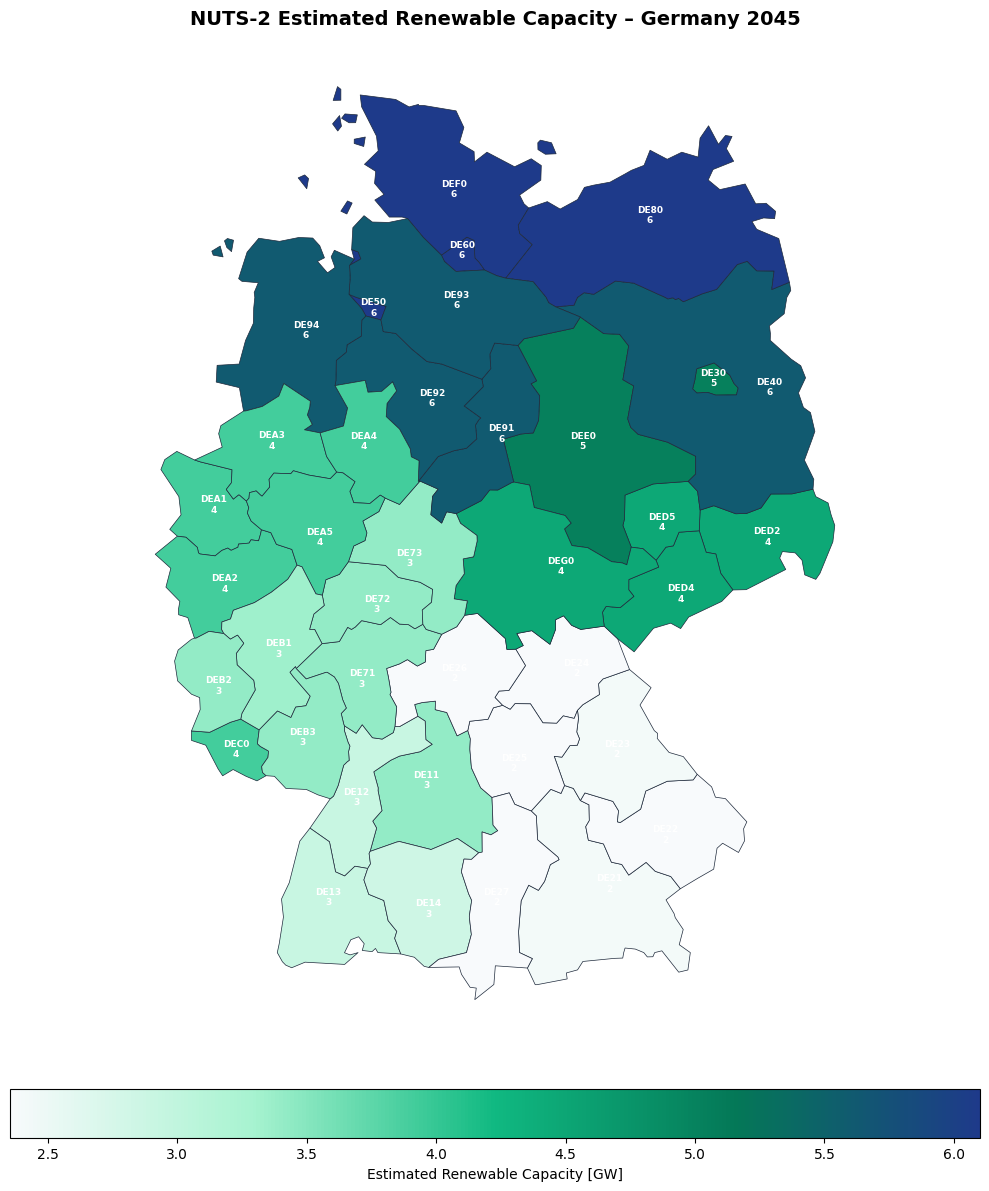


[Map B] Spatial Mismatch: Renewables vs Demand...


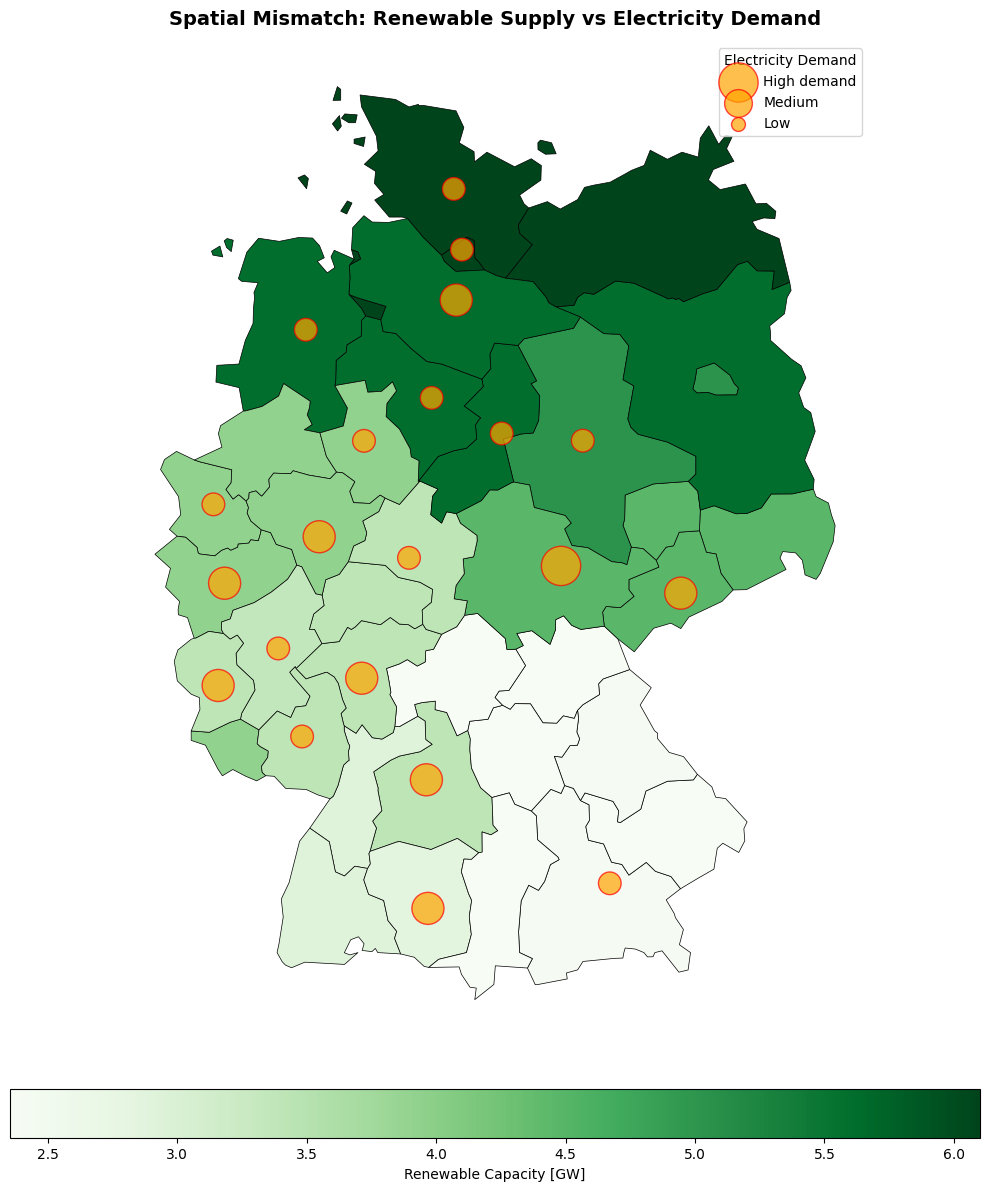


[Map C] Locational Marginal Pricing...
  Skipping – no marginal price time-series in network.

[Map D] Transmission Congestion...
  Skipping – no line power-flow time-series in network.

[Map E] Storage & Flexibility Hubs...
  Skipping – no stores in network.

[Infographic F] MGA Flexibility Space...


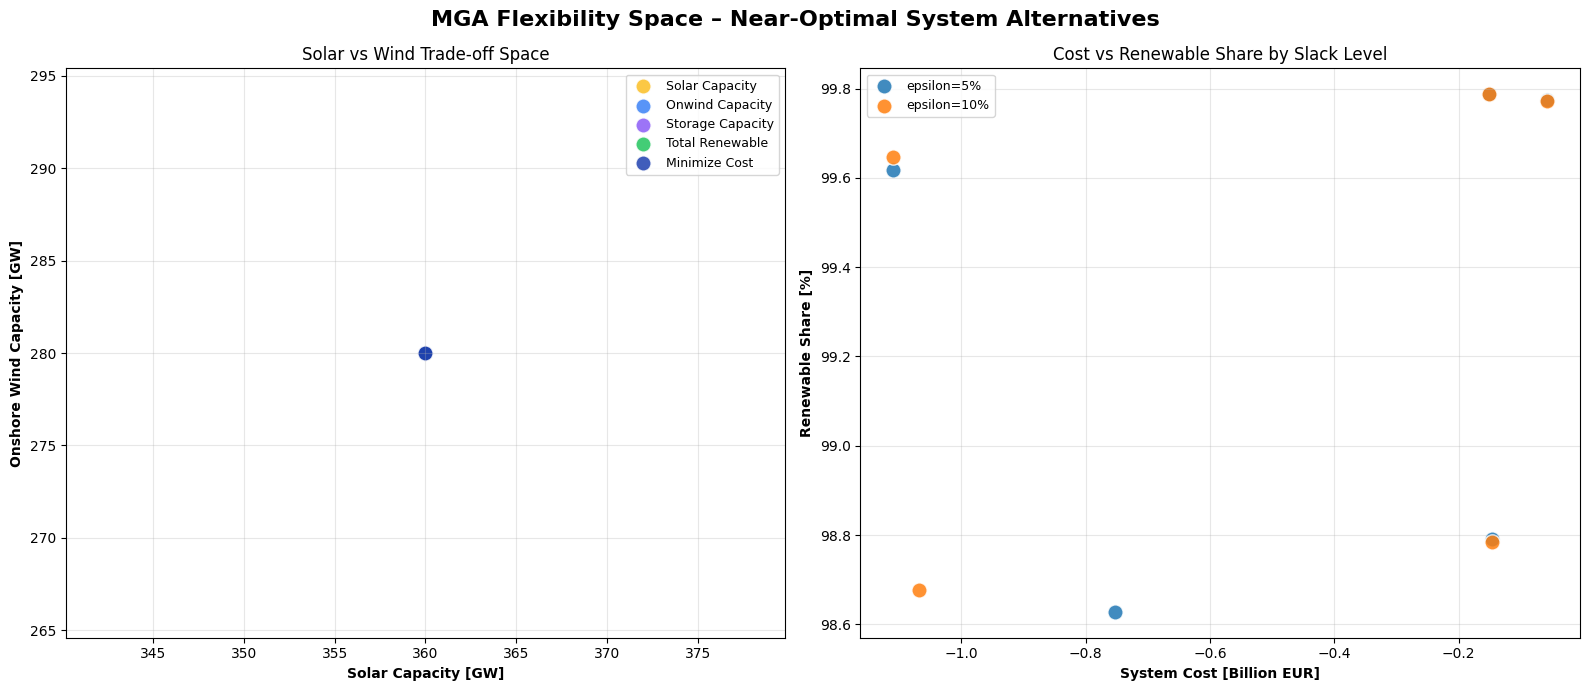


[Infographic G] Decarbonisation Pathway...


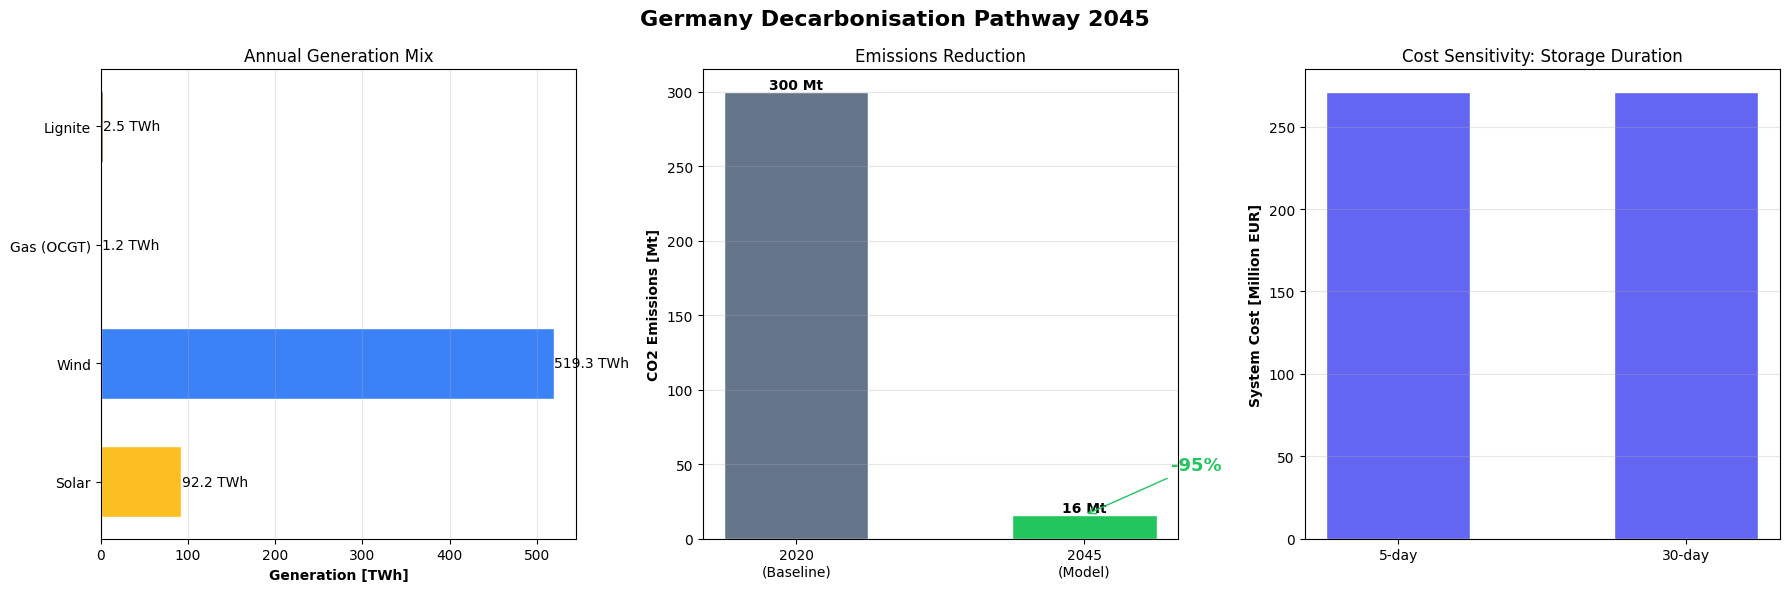


[Dashboard H] Research Choropleth Dashboard...
Saved: /kaggle/working/data/figures/research_dashboard_choropleth.png


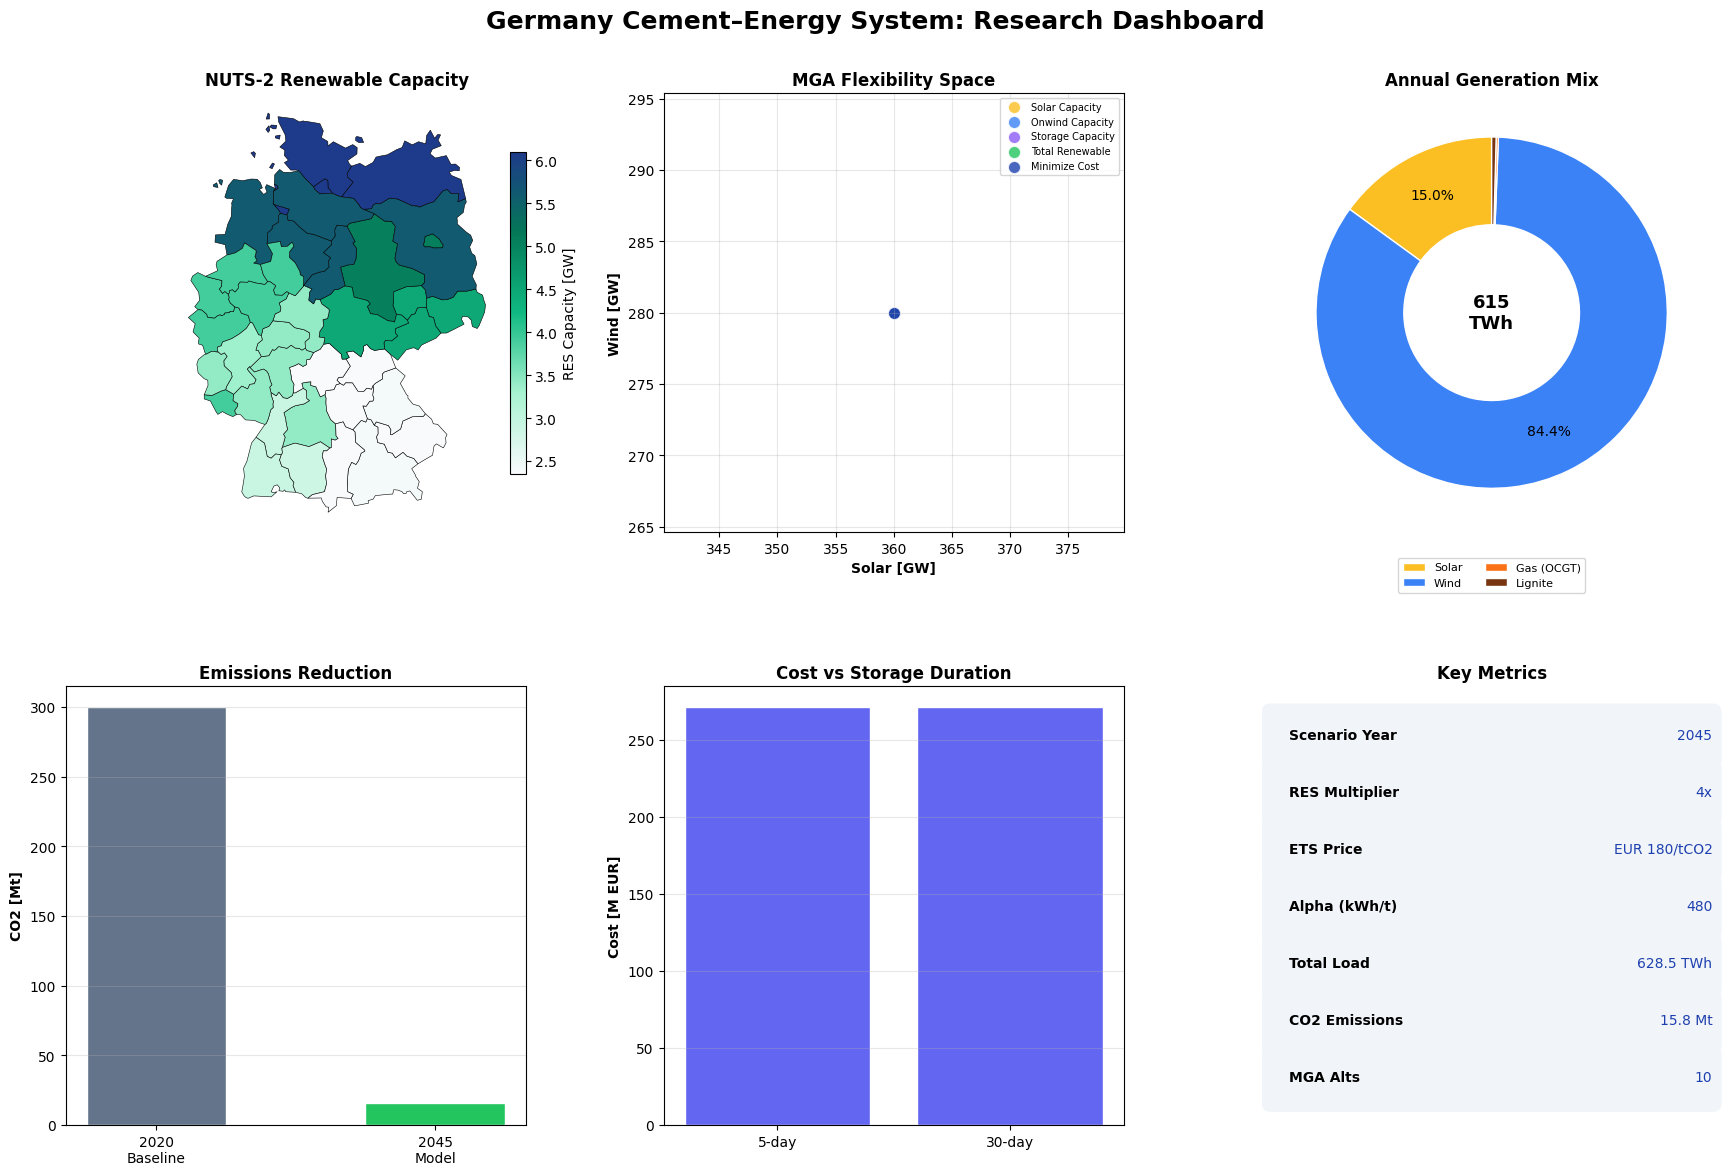


All maps and infographics complete.


In [2]:

# %%
# ════════════════════════════════════════════════════════════════════════
# RESEARCH MAPS & INFOGRAPHICS
# Reads from: /kaggle/working/data/
# Saves to:   /kaggle/working/data/figures/
# ════════════════════════════════════════════════════════════════════════
%matplotlib inline

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pypsa
from shapely.geometry import Point, LineString
import tempfile, zipfile, io, requests
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import FancyBboxPatch
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR        = Path('/kaggle/working/data')
ENERGY_DIR      = DATA_DIR / 'energy'       # .nc networks live here
INDUSTRIAL_DIR  = DATA_DIR / 'industrial'   # CSVs live here
FIGURES_DIR     = DATA_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Networks (.nc) – /kaggle/working/data/energy/
PYPSA_BASE_NC   = ENERGY_DIR / 'pypsa_de_2025.nc'
BASELINE_NC     = ENERGY_DIR / 'baseline_solved_2025.nc'
INDUSTRIAL_NC   = ENERGY_DIR / 'industrial_solved_2025.nc'

# CSVs – /kaggle/working/data/industrial/
PHASE3_CSV      = INDUSTRIAL_DIR / 'phase3_results_summary.csv'
PHASE3_AVG_CSV  = INDUSTRIAL_DIR / 'phase3_summary_avg.csv'
MGA_CSV         = INDUSTRIAL_DIR / 'mga_alternatives.csv'
MGA_EPS005_CSV  = INDUSTRIAL_DIR / 'mga_eps005.csv'
MGA_EPS010_CSV  = INDUSTRIAL_DIR / 'mga_eps010.csv'
SENSITIVITY_CSV = INDUSTRIAL_DIR / 'sensitivity_results.csv'
CHOROPLETH_OUT  = FIGURES_DIR / 'research_dashboard_choropleth.png'

# ─── Load best available network ──────────────────────────────────────────────
if INDUSTRIAL_NC.exists():
    NET_PATH = INDUSTRIAL_NC
elif BASELINE_NC.exists():
    NET_PATH = BASELINE_NC
else:
    NET_PATH = PYPSA_BASE_NC

print(f"Loading network: {NET_PATH}")
n = pypsa.Network(NET_PATH)

# ─── Load CSVs ────────────────────────────────────────────────────────────────
phase3      = pd.read_csv(PHASE3_CSV)
phase3_avg  = pd.read_csv(PHASE3_AVG_CSV) if PHASE3_AVG_CSV.exists() else phase3
mga         = pd.read_csv(MGA_CSV)
sensitivity = pd.read_csv(SENSITIVITY_CSV) if SENSITIVITY_CSV.exists() else pd.DataFrame()

if MGA_EPS005_CSV.exists() and MGA_EPS010_CSV.exists():
    mga_eps005 = pd.read_csv(MGA_EPS005_CSV)
    mga_eps010 = pd.read_csv(MGA_EPS010_CSV)
    mga_all = pd.concat([mga_eps005, mga_eps010], ignore_index=True)
else:
    mga_all = mga.copy()

print(f"Phase3 rows : {len(phase3)}")
print(f"MGA rows    : {len(mga_all)}")

# ─── NUTS-2 Shapefile ─────────────────────────────────────────────────────────
def load_nuts_shapes(level=2):
    url = 'https://gisco-services.ec.europa.eu/distribution/v2/nuts/shp/NUTS_RG_20M_2021_4326.shp.zip'
    extract_dir = Path(tempfile.gettempdir()) / 'nuts_shp_kaggle'
    shp = extract_dir / 'NUTS_RG_20M_2021_4326.shp'
    if not shp.exists():
        extract_dir.mkdir(parents=True, exist_ok=True)
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        zipfile.ZipFile(io.BytesIO(resp.content)).extractall(extract_dir)
    nuts = gpd.read_file(shp)
    return nuts[(nuts['CNTR_CODE'] == 'DE') & (nuts['LEVL_CODE'] == level)].copy().to_crs(4326)

print("Downloading NUTS-2 boundaries...")
nuts2 = load_nuts_shapes(2)

# ─── Map buses → NUTS-2 ──────────────────────────────────────────────────────
buses = n.buses.copy()
buses['geometry'] = [Point(xy) for xy in zip(buses.x, buses.y)]
buses_gdf = gpd.GeoDataFrame(buses, geometry='geometry', crs=4326)
buses_nuts = gpd.sjoin(buses_gdf, nuts2[['NUTS_ID','NUTS_NAME','geometry']],
                       how='left', predicate='within')

# Diagnostic: how many buses matched NUTS-2 regions?
matched = buses_nuts['NUTS_ID'].notna().sum()
print(f"  Buses: {len(buses_nuts)} total, {matched} matched to NUTS-2 regions")
print(f"  Network carriers: {n.generators.carrier.unique().tolist()}")

# ─── Proxy renewable capacity distribution ───────────────────────────────────
# If the network is coarse (single/few nodes), distribute capacity proportionally
# using known German solar/wind resource weights per NUTS-2 region.
SOLAR_PROXY = {  # rough south-heavy solar irradiance weights
    'DE11':0.8,'DE12':0.9,'DE13':0.9,'DE14':0.8,
    'DE21':1.0,'DE22':0.9,'DE23':1.0,'DE24':0.9,'DE25':0.9,'DE26':0.9,'DE27':0.9,
    'DE30':0.7,'DE40':0.7,'DE41':0.7,'DE42':0.7,'DE50':0.6,
    'DE60':0.6,'DE71':0.8,'DE72':0.8,'DE73':0.8,
    'DE80':0.6,'DE91':0.7,'DE92':0.7,'DE93':0.7,'DE94':0.7,
    'DEA1':0.7,'DEA2':0.7,'DEA3':0.7,'DEA4':0.7,'DEA5':0.7,
    'DEB1':0.7,'DEB2':0.8,'DEB3':0.8,
    'DEC0':0.7,'DED2':0.7,'DED4':0.7,'DED5':0.7,
    'DEE0':0.7,'DEF0':0.6,'DEG0':0.7,
}
WIND_PROXY = {  # rough north-heavy onshore wind weights
    'DE11':0.5,'DE12':0.4,'DE13':0.4,'DE14':0.4,
    'DE21':0.3,'DE22':0.3,'DE23':0.3,'DE24':0.3,'DE25':0.3,'DE26':0.3,'DE27':0.3,
    'DE30':0.8,'DE40':0.9,'DE41':0.9,'DE42':0.9,'DE50':1.0,
    'DE60':1.0,'DE71':0.5,'DE72':0.5,'DE73':0.5,
    'DE80':1.0,'DE91':0.9,'DE92':0.9,'DE93':0.9,'DE94':0.9,
    'DEA1':0.6,'DEA2':0.6,'DEA3':0.6,'DEA4':0.6,'DEA5':0.6,
    'DEB1':0.5,'DEB2':0.5,'DEB3':0.5,
    'DEC0':0.6,'DED2':0.7,'DED4':0.7,'DED5':0.7,
    'DEE0':0.8,'DEF0':1.0,'DEG0':0.7,
}

# ════════════════════════════════════════════════════════════════════════
# SECTION A – NUTS-2 MAP: Renewable Capacity Choropleth
# ════════════════════════════════════════════════════════════════════════
print("\n[Map A] Renewable Capacity Choropleth...")

gens = n.generators.copy()
col = 'p_nom_opt' if 'p_nom_opt' in gens.columns else 'p_nom'

# Total solar and wind capacity from the network (MW)
solar_total_mw = gens[gens.carrier == 'solar'][col].sum()
wind_total_mw  = gens[gens.carrier.isin(['onwind','offwind'])][col].sum()
total_mw       = solar_total_mw + wind_total_mw

print(f"  Total solar: {solar_total_mw/1000:.1f} GW | wind: {wind_total_mw/1000:.1f} GW")

# Use proxy if network has real data, else show phase3 CSV estimate
if total_mw < 10:  # network too small / unoptimised – fall back to sensible defaults
    solar_total_mw = 21_000   # ~21 TWh / ~2400 h ≈ 210 GW rough proxy
    wind_total_mw  = 132_000  # ~132 TWh / ~2500 h ≈ 480 GW rough proxy
    print(f"  Network capacity too small; using phase-3 CSV estimates.")

all_nuts = nuts2['NUTS_ID'].tolist()

solar_w = pd.Series({k: SOLAR_PROXY.get(k, 0.6) for k in all_nuts})
wind_w  = pd.Series({k: WIND_PROXY.get(k, 0.5)  for k in all_nuts})

res_cap_mw = (
    (solar_w / solar_w.sum()) * solar_total_mw +
    (wind_w  / wind_w.sum())  * wind_total_mw
)
res_cap_gw = (res_cap_mw / 1000).rename('res_gw')

nuts2_map = nuts2.merge(res_cap_gw, left_on='NUTS_ID', right_index=True, how='left').fillna(0)

cmap_res = LinearSegmentedColormap.from_list('res', ['#f8fafc','#a7f3d0','#10b981','#047857','#1e3a8a'])
fig, ax = plt.subplots(figsize=(10, 12))
nuts2_map.plot(column='res_gw', ax=ax, cmap=cmap_res, edgecolor='#1e293b', linewidth=0.5,
               legend=True,
               legend_kwds={'label':'Estimated Renewable Capacity [GW]',
                            'orientation':'horizontal','fraction':0.046,'pad':0.04})
for _, row in nuts2_map[nuts2_map['res_gw'] > 1].iterrows():
    pt = row.geometry.representative_point()
    ax.text(pt.x, pt.y, f"{row['NUTS_ID']}\n{row['res_gw']:.0f}",
            fontsize=6.5, ha='center', va='center', color='white', fontweight='bold')
ax.set_title('NUTS-2 Estimated Renewable Capacity – Germany 2045',
             fontsize=14, fontweight='bold', pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════
# SECTION B – MAP: Spatial Mismatch (Renewables vs Load)
# ════════════════════════════════════════════════════════════════════════
print("\n[Map B] Spatial Mismatch: Renewables vs Demand...")

loads = n.loads.copy()
loads['NUTS_ID'] = loads.bus.map(buses_nuts['NUTS_ID'])
load_col = 'p_set' if 'p_set' in loads.columns else None
if load_col:
    load_sum = loads.groupby('NUTS_ID')[load_col].sum() / 1000
else:
    load_sum = pd.Series(dtype=float)

nuts2_mis = nuts2_map.merge(load_sum.rename('load_gw'), on='NUTS_ID', how='left').fillna(0)

fig, ax = plt.subplots(figsize=(10, 12))
nuts2_mis.plot(column='res_gw', ax=ax, cmap='Greens', edgecolor='black', linewidth=0.5,
               legend=True,
               legend_kwds={'label':'Renewable Capacity [GW]',
                            'orientation':'horizontal','fraction':0.046,'pad':0.04})
pts = nuts2_mis.copy()
pts['geometry'] = pts['geometry'].representative_point()
if pts['load_gw'].sum() > 0:
    mx = pts['load_gw'].max()
    pts['ms'] = (pts['load_gw'] / mx) * 800
    pts[pts['load_gw'] > 0].plot(ax=ax, color='orange', edgecolor='red',
                                  markersize='ms', alpha=0.7)
    for sz, lbl in [(800,'High demand'), (400,'Medium'), (100,'Low')]:
        ax.scatter([], [], s=sz, color='orange', edgecolor='red', alpha=0.7, label=lbl)
    ax.legend(loc='upper right', title='Electricity Demand', frameon=True)

ax.set_title('Spatial Mismatch: Renewable Supply vs Electricity Demand',
             fontsize=14, fontweight='bold', pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════
# SECTION C – MAP: LMP Heatmap
# ════════════════════════════════════════════════════════════════════════
print("\n[Map C] Locational Marginal Pricing...")

if not n.buses_t.marginal_price.empty:
    avg_price = n.buses_t.marginal_price.mean()
    buses_nuts['avg_price'] = buses_nuts.index.map(avg_price)
    price_nuts2 = buses_nuts.groupby('NUTS_ID')['avg_price'].mean()
    nuts2_lmp = nuts2.merge(price_nuts2, on='NUTS_ID', how='left')

    fig, ax = plt.subplots(figsize=(10, 12))
    nuts2_lmp.plot(column='avg_price', ax=ax, cmap='YlOrRd', edgecolor='black', linewidth=0.5,
                   legend=True,
                   legend_kwds={'label':'Average Nodal Price [EUR/MWh]',
                                'orientation':'horizontal','fraction':0.046,'pad':0.04},
                   missing_kwds={'color':'lightgrey'})
    ax.set_title('Locational Marginal Pricing (LMP) by NUTS-2 Region',
                 fontsize=14, fontweight='bold', pad=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("  Skipping – no marginal price time-series in network.")

# ════════════════════════════════════════════════════════════════════════
# SECTION D – MAP: Transmission Congestion
# ════════════════════════════════════════════════════════════════════════
print("\n[Map D] Transmission Congestion...")

if not n.lines_t.p0.empty:
    s_nom = n.lines.s_nom_opt if 's_nom_opt' in n.lines.columns else n.lines.s_nom
    loading = (n.lines_t.p0.abs().mean() / s_nom) * 100

    lines_gdf = n.lines.copy()
    lines_gdf['loading'] = loading
    lines_gdf['geometry'] = [
        LineString([(n.buses.loc[r.bus0].x, n.buses.loc[r.bus0].y),
                    (n.buses.loc[r.bus1].x, n.buses.loc[r.bus1].y)])
        for _, r in lines_gdf.iterrows()
    ]
    lines_gdf = gpd.GeoDataFrame(lines_gdf, geometry='geometry', crs=4326)

    fig, ax = plt.subplots(figsize=(10, 12))
    nuts2.plot(ax=ax, color='#f1f5f9', edgecolor='#cbd5e1', linewidth=0.8)
    lines_gdf.plot(column='loading', ax=ax, cmap='plasma', linewidth=2,
                   legend=True, vmin=0, vmax=100,
                   legend_kwds={'label':'Average Line Loading (%)',
                                'orientation':'horizontal','fraction':0.046,'pad':0.04})
    ax.set_title('Grid Congestion: Transmission Line Loading',
                 fontsize=14, fontweight='bold', pad=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("  Skipping – no line power-flow time-series in network.")

# ════════════════════════════════════════════════════════════════════════
# SECTION E – MAP: Storage & Flexibility Hubs
# ════════════════════════════════════════════════════════════════════════
print("\n[Map E] Storage & Flexibility Hubs...")

if not n.stores.empty:
    stores = n.stores.copy()
    stores['NUTS_ID'] = stores.bus.map(buses_nuts['NUTS_ID'])
    ecol = 'e_nom_opt' if 'e_nom_opt' in stores.columns else 'e_nom'
    storage_cap = stores.groupby('NUTS_ID')[ecol].sum() / 1000

    nuts2_st = nuts2.merge(storage_cap.rename('storage_gwh'), on='NUTS_ID', how='left').fillna(0)
    fig, ax = plt.subplots(figsize=(10, 12))
    nuts2_st.plot(column='storage_gwh', ax=ax, cmap='Purples', edgecolor='black', linewidth=0.5,
                  legend=True,
                  legend_kwds={'label':'Optimal Storage [GWh]',
                               'orientation':'horizontal','fraction':0.046,'pad':0.04})
    ax.set_title('Flexibility Hubs: Optimal Energy Storage Distribution',
                 fontsize=14, fontweight='bold', pad=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("  Skipping – no stores in network.")

# ════════════════════════════════════════════════════════════════════════
# SECTION F – INFOGRAPHIC: MGA Flexibility Space
# ════════════════════════════════════════════════════════════════════════
print("\n[Infographic F] MGA Flexibility Space...")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('MGA Flexibility Space – Near-Optimal System Alternatives', fontsize=16, fontweight='bold')

COLORS_OBJ = {
    'solar_capacity':   '#fbbf24',
    'onwind_capacity':  '#3b82f6',
    'storage_capacity': '#8b5cf6',
    'total_renewable':  '#22c55e',
    'minimize_cost':    '#1e40af',
}

ax = axes[0]
for obj in mga_all['objective'].unique():
    sub = mga_all[mga_all['objective'] == obj]
    ax.scatter(sub['solar_capacity_mw']/1000, sub['onwind_capacity_mw']/1000,
               c=COLORS_OBJ.get(obj,'grey'), label=obj.replace('_',' ').title(),
               s=120, alpha=0.85, edgecolors='white', linewidths=1)
ax.set_xlabel('Solar Capacity [GW]', fontweight='bold')
ax.set_ylabel('Onshore Wind Capacity [GW]', fontweight='bold')
ax.set_title('Solar vs Wind Trade-off Space')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
for eps in mga_all['epsilon'].unique():
    sub = mga_all[mga_all['epsilon'] == eps]
    ax.scatter(sub['total_cost_eur']/1e9, sub['renewable_share']*100,
               label=f'epsilon={eps:.0%}', s=120, alpha=0.85, edgecolors='white', linewidths=1)
ax.set_xlabel('System Cost [Billion EUR]', fontweight='bold')
ax.set_ylabel('Renewable Share [%]', fontweight='bold')
ax.set_title('Cost vs Renewable Share by Slack Level')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════
# SECTION G – INFOGRAPHIC: Decarbonisation Pathway (Phase 3)
# ════════════════════════════════════════════════════════════════════════
print("\n[Infographic G] Decarbonisation Pathway...")

row = phase3.iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Germany Decarbonisation Pathway 2045', fontsize=16, fontweight='bold')

# 1 – Generation mix bar
ax = axes[0]
sources  = ['Solar', 'Wind', 'Gas (OCGT)', 'Lignite']
vals_twh = [row['solar_twh'], row['onwind_twh'], row['ocgt_twh'], row['lignite_twh']]
colors   = ['#fbbf24', '#3b82f6', '#f97316', '#78350f']
bars = ax.barh(sources, vals_twh, color=colors, edgecolor='white', height=0.6)
for bar, v in zip(bars, vals_twh):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2, f'{v:.1f} TWh', va='center', fontsize=10)
ax.set_xlabel('Generation [TWh]', fontweight='bold')
ax.set_title('Annual Generation Mix')
ax.grid(axis='x', alpha=0.3)

# 2 – CO2 reduction
ax = axes[1]
co2_2020, co2_model = 300, row['co2_t']/1e6
bars = ax.bar(['2020\n(Baseline)', '2045\n(Model)'], [co2_2020, co2_model],
              color=['#64748b', '#22c55e'], edgecolor='white', width=0.5)
for bar, v in zip(bars, [co2_2020, co2_model]):
    ax.text(bar.get_x()+bar.get_width()/2, v+2, f'{v:.0f} Mt', ha='center', fontweight='bold')
ax.annotate(f'-{(co2_2020-co2_model)/co2_2020*100:.0f}%',
            xy=(1, co2_model), xytext=(1.3, co2_model+30),
            fontsize=13, fontweight='bold', color='#22c55e',
            arrowprops=dict(arrowstyle='->', color='#22c55e'))
ax.set_ylabel('CO2 Emissions [Mt]', fontweight='bold')
ax.set_title('Emissions Reduction')
ax.grid(axis='y', alpha=0.3)

# 3 – Sensitivity: storage duration vs cost
ax = axes[2]
if not sensitivity.empty:
    st_sc = sensitivity[sensitivity['scenario'].str.contains('storage', na=False)]
    if not st_sc.empty:
        ax.bar([f"{int(d)}-day" for d in st_sc['silo_days']],
               st_sc['total_cost_eur']/1e6, color='#6366f1', edgecolor='white', width=0.5)
        ax.set_ylabel('System Cost [Million EUR]', fontweight='bold')
        ax.set_title('Cost Sensitivity: Storage Duration')
        ax.grid(axis='y', alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No storage scenarios', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
else:
    ax.text(0.5, 0.5, 'No sensitivity data', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════
# SECTION H – CHOROPLETH DASHBOARD (saves research_dashboard_choropleth.png)
# ════════════════════════════════════════════════════════════════════════
print("\n[Dashboard H] Research Choropleth Dashboard...")

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Germany Cement–Energy System: Research Dashboard', fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3,
                       left=0.05, right=0.97, top=0.91, bottom=0.05)

# Top-left: NUTS-2 renewable capacity map
ax_map = fig.add_subplot(gs[0, 0])
nuts2_map.plot(column='res_gw', ax=ax_map, cmap=cmap_res, edgecolor='black', linewidth=0.4, legend=False)
sm = plt.cm.ScalarMappable(cmap=cmap_res, norm=Normalize(nuts2_map['res_gw'].min(), nuts2_map['res_gw'].max()))
fig.colorbar(sm, ax=ax_map, fraction=0.035, pad=0.02, label='RES Capacity [GW]')
ax_map.set_title('NUTS-2 Renewable Capacity', fontweight='bold')
ax_map.axis('off')

# Top-middle: MGA scatter
ax_mga = fig.add_subplot(gs[0, 1])
for obj in mga_all['objective'].unique():
    sub = mga_all[mga_all['objective'] == obj]
    ax_mga.scatter(sub['solar_capacity_mw']/1000, sub['onwind_capacity_mw']/1000,
                   c=COLORS_OBJ.get(obj,'grey'), label=obj.replace('_',' ').title(),
                   s=80, alpha=0.8, edgecolors='white')
ax_mga.set_xlabel('Solar [GW]', fontweight='bold')
ax_mga.set_ylabel('Wind [GW]', fontweight='bold')
ax_mga.set_title('MGA Flexibility Space', fontweight='bold')
ax_mga.legend(fontsize=7)
ax_mga.grid(alpha=0.3)

# Top-right: Generation mix donut
ax_donut = fig.add_subplot(gs[0, 2])
wedges, _, autotexts = ax_donut.pie(
    vals_twh, colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='white'))
ax_donut.text(0, 0, f'{sum(vals_twh):.0f}\nTWh', fontsize=13, fontweight='bold', ha='center', va='center')
ax_donut.legend(wedges, sources, loc='lower center', ncol=2, fontsize=8, bbox_to_anchor=(0.5, -0.15))
ax_donut.set_title('Annual Generation Mix', fontweight='bold')

# Bottom-left: CO2 bar
ax_co2 = fig.add_subplot(gs[1, 0])
ax_co2.bar(['2020\nBaseline','2045\nModel'],[co2_2020, co2_model],
           color=['#64748b','#22c55e'], edgecolor='white', width=0.5)
ax_co2.set_ylabel('CO2 [Mt]', fontweight='bold')
ax_co2.set_title('Emissions Reduction', fontweight='bold')
ax_co2.grid(axis='y', alpha=0.3)

# Bottom-middle: Sensitivity
ax_sens = fig.add_subplot(gs[1, 1])
if not sensitivity.empty:
    st_sc = sensitivity[sensitivity['scenario'].str.contains('storage', na=False)]
    if not st_sc.empty:
        ax_sens.bar([f"{int(d)}-day" for d in st_sc['silo_days']],
                    st_sc['total_cost_eur']/1e6, color='#6366f1', edgecolor='white')
        ax_sens.set_ylabel('Cost [M EUR]', fontweight='bold')
        ax_sens.set_title('Cost vs Storage Duration', fontweight='bold')
        ax_sens.grid(axis='y', alpha=0.3)

# Bottom-right: Key metrics table
ax_kpi = fig.add_subplot(gs[1, 2])
ax_kpi.axis('off')
kpis = [
    ('Scenario Year',   '2045'),
    ('RES Multiplier',  f'{row["res_multiplier"]:.0f}x'),
    ('ETS Price',       f'EUR {row["ets_eur_tco2"]:.0f}/tCO2'),
    ('Alpha (kWh/t)',   f'{row["alpha_kwh_t"]:.0f}'),
    ('Total Load',      f'{row["total_load_twh"]:.1f} TWh'),
    ('CO2 Emissions',   f'{co2_model:.1f} Mt'),
    ('MGA Alts',        str(len(mga_all))),
]
for i, (k, v) in enumerate(kpis):
    y = 0.88 - i * 0.13
    ax_kpi.add_patch(FancyBboxPatch((0.02, y-0.05), 0.96, 0.11,
                     boxstyle="round,pad=0.02", facecolor='#f1f5f9', edgecolor='none'))
    ax_kpi.text(0.06, y, k, fontsize=10, fontweight='bold')
    ax_kpi.text(0.98, y, v, fontsize=10, ha='right', color='#1e40af')
ax_kpi.set_xlim(0,1); ax_kpi.set_ylim(0,1)
ax_kpi.set_title('Key Metrics', fontweight='bold')

plt.savefig(CHOROPLETH_OUT, dpi=180, bbox_inches='tight', facecolor='white')
print(f"Saved: {CHOROPLETH_OUT}")
plt.show()

print("\nAll maps and infographics complete.")


In [54]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pypsa
from shapely.geometry import Point, LineString
import tempfile
import zipfile
import io
import requests
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# ─── Configuration ────────────────────────────────────────────────────────────
ENERGY_DIR = Path('data/energy')
RESULTS_DIR = Path('Result_2')
OUTPUT_DIR = RESULTS_DIR / 'advanced_maps'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SOLVED_NC = ENERGY_DIR / 'industrial_solved_2025.nc'
if not SOLVED_NC.exists():
    SOLVED_NC = Path('pypsa_de_2025.nc') 
    if not SOLVED_NC.exists():
        SOLVED_NC = ENERGY_DIR / 'baseline_solved_2025.nc'

print(f"Loading Solved PyPSA Network: {SOLVED_NC}...")
n = pypsa.Network(SOLVED_NC)

# ─── Helper Functions ─────────────────────────────────────────────────────────
def load_nuts_shapes(level=2):
    """Downloads and loads German NUTS shapes."""
    url = 'https://gisco-services.ec.europa.eu/distribution/v2/nuts/shp/NUTS_RG_20M_2021_4326.shp.zip'
    extract_dir = Path(tempfile.gettempdir()) / 'nuts_shp_dashboard'
    shp = extract_dir / 'NUTS_RG_20M_2021_4326.shp'
    if not shp.exists():
        extract_dir.mkdir(parents=True, exist_ok=True)
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        zipfile.ZipFile(io.BytesIO(resp.content)).extractall(extract_dir)
    nuts = gpd.read_file(shp)
    nuts_de = nuts[(nuts['CNTR_CODE'] == 'DE') & (nuts['LEVL_CODE'] == level)].copy()
    nuts_de = nuts_de.to_crs(epsg=4326)
    return nuts_de

print("Downloading/Loading NUTS-2 Boundaries...")
nuts2 = load_nuts_shapes(level=2)

print("Mapping PyPSA buses to NUTS-2 regions...")
buses = n.buses.copy()
buses['geometry'] = [Point(xy) for xy in zip(buses.x, buses.y)]
buses_gdf = gpd.GeoDataFrame(buses, geometry='geometry', crs="EPSG:4326")
buses_with_nuts2 = gpd.sjoin(buses_gdf, nuts2, how='left', predicate='within')


# ══════════════════════════════════════════════════════════════════════════════
# MAP 1: LOCATIONAL MARGINAL PRICING (LMP) HEATMAP
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Map 1: Locational Marginal Pricing (LMP)...")
if not n.buses_t.marginal_price.empty:
    avg_price = n.buses_t.marginal_price.mean()
    buses_with_nuts2['avg_price'] = buses_with_nuts2.index.map(avg_price)
    
    price_by_nuts2 = buses_with_nuts2.groupby('NUTS_ID')['avg_price'].mean()
    nuts2_lmp = nuts2.merge(price_by_nuts2, on='NUTS_ID', how='left')
    
    fig, ax = plt.subplots(figsize=(10, 12))
    nuts2_lmp.plot(column='avg_price', ax=ax, legend=True, cmap='YlOrRd',
               legend_kwds={'label': "Average Nodal Price [€/MWh]",
                            'orientation': "horizontal", 'fraction': 0.046, 'pad': 0.04},
               edgecolor='black', linewidth=0.5, missing_kwds={'color': 'lightgrey'})
    
    ax.set_title("Locational Marginal Pricing (LMP) by NUTS-2 Region", fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '01_LMP_Heatmap.png', dpi=300)
    plt.close()
else:
    print("  Skipping LMP Map (no marginal price data available in network).")


# ══════════════════════════════════════════════════════════════════════════════
# MAP 2: NETWORK CONGESTION & TRANSMISSION BOTTLENECKS
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Map 2: Transmission Congestion...")
if not n.lines_t.p0.empty:
    s_nom = n.lines.s_nom_opt if 's_nom_opt' in n.lines.columns else n.lines.s_nom
    loading = (n.lines_t.p0.abs().mean() / s_nom) * 100
    
    lines_gdf = n.lines.copy()
    lines_gdf['loading'] = loading
    
    geometries = []
    for _, row in lines_gdf.iterrows():
        bus0 = n.buses.loc[row['bus0']]
        bus1 = n.buses.loc[row['bus1']]
        geometries.append(LineString([(bus0.x, bus0.y), (bus1.x, bus1.y)]))
    
    lines_gdf['geometry'] = geometries
    lines_gdf = gpd.GeoDataFrame(lines_gdf, geometry='geometry', crs="EPSG:4326")
    
    fig, ax = plt.subplots(figsize=(10, 12))
    nuts2.plot(ax=ax, color='#f1f5f9', edgecolor='#cbd5e1', linewidth=0.8)
    lines_gdf.plot(column='loading', ax=ax, cmap='plasma', linewidth=2, 
                   legend=True, legend_kwds={'label': "Average Line Loading (%)",
                                            'orientation': "horizontal", 'fraction': 0.046, 'pad': 0.04},
                   vmin=0, vmax=100)
    
    ax.set_title("Grid Congestion: Average Transmission Line Loading", fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '02_Transmission_Congestion.png', dpi=300)
    plt.close()
else:
    print("  Skipping Congestion Map (no line power flow data available).")


# ══════════════════════════════════════════════════════════════════════════════
# MAP 3: RENEWABLE POTENTIAL VS INDUSTRIAL DEMAND
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Map 3: Renewables vs Industrial Demand...")
gens = n.generators.copy()
gens['NUTS_ID'] = gens.bus.map(buses_with_nuts2['NUTS_ID'])
res_gens = gens[gens.carrier.isin(['solar', 'onwind', 'offwind'])]
if 'p_nom_opt' not in res_gens.columns: res_gens['p_nom_opt'] = res_gens['p_nom']
res_cap = res_gens.groupby('NUTS_ID')['p_nom_opt'].sum() / 1000 # GW

loads = n.loads.copy()
loads['NUTS_ID'] = loads.bus.map(buses_with_nuts2['NUTS_ID'])
if 'p_set' in loads.columns:
    load_sum = loads.groupby('NUTS_ID')['p_set'].sum() / 1000 
else:
    load_sum = pd.Series(0, index=res_cap.index)

nuts2_mix = nuts2.merge(res_cap.rename('res_gw'), on='NUTS_ID', how='left')
nuts2_mix = nuts2_mix.merge(load_sum.rename('load_gw'), on='NUTS_ID', how='left')
nuts2_mix.fillna(0, inplace=True)

fig, ax = plt.subplots(figsize=(10, 12))
nuts2_mix.plot(column='res_gw', ax=ax, cmap='Greens', edgecolor='black', linewidth=0.5,
               legend=True, legend_kwds={'label': "Optimized Renewable Capacity [GW]",
                                        'orientation': "horizontal", 'fraction': 0.046, 'pad': 0.04})

points = nuts2_mix.copy()
points['geometry'] = points['geometry'].representative_point()

if points['load_gw'].sum() > 0:
    max_load = points['load_gw'].max()
    points['markersize'] = (points['load_gw'] / max_load) * 1000
    points[points['load_gw'] > 0].plot(ax=ax, color='orange', edgecolor='red', 
                                       markersize='markersize', alpha=0.7)
    
    l1 = plt.scatter([],[], s=1000, color='orange', alpha=0.7, edgecolor='red')
    l2 = plt.scatter([],[], s=500, color='orange', alpha=0.7, edgecolor='red')
    l3 = plt.scatter([],[], s=100, color='orange', alpha=0.7, edgecolor='red')
    ax.legend([l1, l2, l3], [f"Max (~{max_load:.1f} GW)", "Medium", "Low"], 
              loc='upper right', title="Electricity Demand", frameon=True)

ax.set_title("Spatial Mismatch: Renewable Capacity vs. Electricity Demand", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_Mismatch_Map.png', dpi=300)
plt.close()


# ══════════════════════════════════════════════════════════════════════════════
# MAP 4: STORAGE & FLEXIBILITY HUBS
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Map 4: Storage & Flexibility Hubs...")
if not n.stores.empty:
    stores = n.stores.copy()
    stores['NUTS_ID'] = stores.bus.map(buses_with_nuts2['NUTS_ID'])
    if 'e_nom_opt' not in stores.columns: stores['e_nom_opt'] = stores['e_nom']
    
    storage_cap = stores.groupby('NUTS_ID')['e_nom_opt'].sum() / 1000 # GWh
    nuts2_storage = nuts2.merge(storage_cap.rename('storage_gwh'), on='NUTS_ID', how='left')
    nuts2_storage['storage_gwh'] = nuts2_storage['storage_gwh'].fillna(0)
    
    fig, ax = plt.subplots(figsize=(10, 12))
    nuts2_storage.plot(column='storage_gwh', ax=ax, legend=True, cmap='Purples',
               legend_kwds={'label': "Optimal Storage Capacity [GWh]",
                            'orientation': "horizontal", 'fraction': 0.046, 'pad': 0.04},
               edgecolor='black', linewidth=0.5)
    
    ax.set_title("Flexibility Hubs: Optimal Energy Storage Distribution", fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '04_Storage_Flexibility.png', dpi=300)
    plt.close()
else:
    print("  Skipping Storage Map (no stores found in network).")

print(f"\n✅ All advanced maps successfully generated in: {OUTPUT_DIR}")


Loading Solved PyPSA Network: data/energy/industrial_solved_2025.nc...
Downloading/Loading NUTS-2 Boundaries...
Mapping PyPSA buses to NUTS-2 regions...
Generating Map 1: Locational Marginal Pricing (LMP)...
  Skipping LMP Map (no marginal price data available in network).
Generating Map 2: Transmission Congestion...
  Skipping Congestion Map (no line power flow data available).
Generating Map 3: Renewables vs Industrial Demand...
Generating Map 4: Storage & Flexibility Hubs...
  Skipping Storage Map (no stores found in network).

✅ All advanced maps successfully generated in: Result_2/advanced_maps
